
# ===========================================
# FINAL PROJECT
# Hotel Booking Cancellation Specialist
# Binary Classification - Hotel Reservation Cancellation
# ===========================================

Nama : Maulana Abdul Aziz

NPM : 50425612

Kelas : 1IA04

# **1. Data Understanding**


## 1.1 Import Library
**Tujuan**

- Mengimpor library yang akan digunakan

In [1]:
# Analisis Data
import pandas as pd
import numpy as np

# Visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

# Interpretasi
# - Mengimpor library analisis data (pandas, numpy)
# - Membuat visualisasi (matplotlib, seaborn)
# - Kedepannya akan ada import modul tertentu kembali (matplotlib & seaborn yang lebih spesifik, lalu module machine learning), bukan pada cell ini namun pada cell terkait

## 1.2 Load Dataset

Tujuan

- Memuat dataset hotel booking cancellation dari sumber resmi dataset.

In [2]:
url = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2020/2020-02-11/hotels.csv"
df = pd.read_csv(url)

# Interpretasi
# - Dataset diambil langsung ke sumber online menggunakan URL
# - Fungsi df sebagai pembaca dataset dari sumber

## 1.3 Dataset Overview

Tujuan
- Melihat & memahami ukuran data, struktur data secara umum
- Mengidentifikasi tipe data dan ringkasan statistik
- Berkenalan dengan dataset secara keseluruhan

In [3]:
# Dataset overview
df.head()

# Interpretasi
# - Setiap baris merepresentasikan satu reservasi hotel.
# - Target yang akan diprediksi adalah is_canceled.
# - Dataset berisi kombinasi fitur numerik dan kategorikal.
# - Terdapat informasi mengenai customer, reservasi, kamar, serta pembayaran.


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [4]:
# Dataset overview
print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]}")

# Interpretasi
# - 119.390 reservasi (booking)
# - Total ada 32 kolom
# - 1 target (is_canceled)
# - 31 kolom feature (sisanya)
# Ukuran dataset cukup besar untuk membangun model klasifikasi yang stabil.


Rows    : 119,390
Columns : 32


In [5]:
# Dataset structure
df.info()

# Interpretasi
# - Tipe data numerik (int64, float64) -> akan dilakukan scaling
# - Tipe data kategorikal (object) -> akan dilakukan encoding
# - Adanya beberapa fitur dengan nilai kosong yang akan dianalisis pada tahap Data Cleaning
# Informasi ini akan digunakan untuk menentukan strategi preprocessing detail pada step berikutnya

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [6]:
# Statistical overview
df.describe().T

# Interpretasi
# - Rentang nilai fitur
# - Rata-rata
# - Distribusi awal
# - Potensi nilai ekstrem atau outlier
# Belum dilakukan analisis outlier pada tahap ini, karena akan dibahas pada Step 3. Data Cleaning & Preparation.

,count,mean,std,min,25%,50%,75%,max
is_canceled,119390.0,0.370416,0.482918,0.00,0.00,0.000,1.0,1.0
lead_time,119390.0,104.011416,106.863097,0.00,18.00,69.000,160.0,737.0
arrival_date_year,119390.0,2016.156554,0.707476,2015.00,2016.00,2016.000,2017.0,2017.0
arrival_date_week_number,119390.0,27.165173,13.605138,1.00,16.00,28.000,38.0,53.0
arrival_date_day_of_month,119390.0,15.798241,8.780829,1.00,8.00,16.000,23.0,31.0
stays_in_weekend_nights,119390.0,0.927599,0.998613,0.00,0.00,1.000,2.0,19.0
stays_in_week_nights,119390.0,2.500302,1.908286,0.00,1.00,2.000,3.0,50.0
adults,119390.0,1.856403,0.579261,0.00,2.00,2.000,2.0,55.0
children,119386.0,0.103890,0.398561,0.00,0.00,0.000,0.0,10.0
babies,119390.0,0.007949,0.097436,0.00,0.00,0.000,0.0,10.0


## 1.4 Feature Mapping (my personal step)

Tujuan
- Mengelompokkan fitur berdasarkan fungsi bisnis agar analisis lebih terstruktur

### Reservation & Time Behavior
- Features yang menggambarkan waktu reservasi dan pola durasi menginap.
### Customer & Booking Behavior
- Features yang menggambarkan karakteristik customer dan riwayat perilaku reservasi.
### Financial & Operations Behavior
- Features yang berkaitan dengan aspek operasional hotel dan komitmen finansial customer.
### Leakage & Technical Features
- Features yang perlu diperiksa lebih lanjut karena berpotensi mengandung informasi outcome (masa depan).

________________________________________
**Alasan Pengelompokan**

•	proses EDA lebih terarah,

•	feature engineering lebih mudah dirancang,

•	insight bisnis lebih mudah diinterpretasikan,

•	proses modeling lebih sistematis.
________________________________________

Gambar struktur terlampir dibawah (AI generated) :


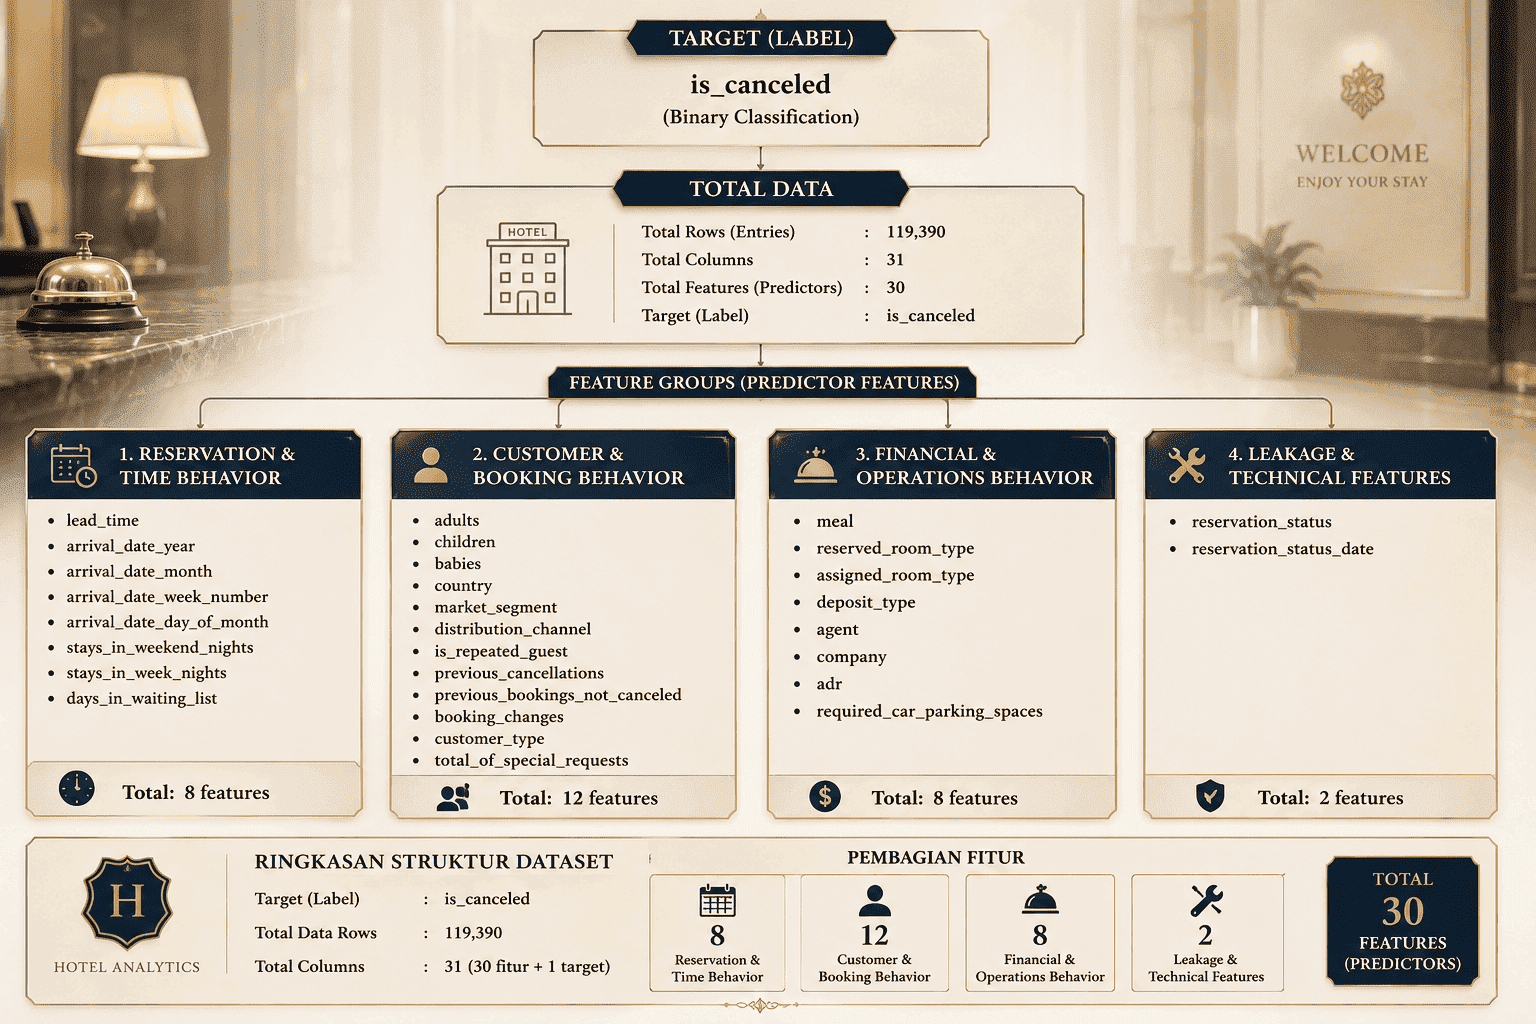

## 1.5 Step 1 Conclusion

Berdasarkan step Data Understanding:

- Dataset terdiri dari 119.390 data reservasi hotel
- Target prediksi adalah is_canceled
- Dataset memiliki kombinasi fitur numerik dan kategorikal
- Fitur telah dikelompokkan menjadi empat kelompok utama: (hanya untuk pemahaman pribadi)
   - Reservation & Time Behavior
   - Customer & Booking Behavior
   - Financial & Operations Behavior
   - Leakage & Technical Features
- Beberapa fitur berpotensi perlu handle khusus pada next step

Selanjutnya pada step 2 Data Cleaning & Preparation, akan berfokus pada:
- data quality assessment,
- missing value treatment,
- consistency checking,
- leakage handling,
- feature preparation.

# **2. Data Cleaning & Preparation**

## 2.1 Create Working Dataset
Tujuan

- Membuat salinan dataset mentah yg akan digunakan selama proses cleaning dan preparation
- Langkah pencegahan yg jauh lebih aman saat manipulasi data dan debugging (drop, imputation, feature engineering)

In [7]:
df_clean = df.copy()

# Copy raw dataset
# df_clean -> menjadi dataset utama yang digunakan pada seluruh proses berikutnya
# df       -> dipertahankan sebagai referensi data mentah apabila diperlukan proses validasi atau rollback

display(df_clean.head())
# Verify

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


## 2.2 Missing Value Audit
Tujuan

- Memeriksa lalu menangani missing value  berdasarkan konteks bisnis dan karakteristik features.


In [8]:
# Missing value check

missing_values = df_clean.isnull().sum()

missing_table = pd.DataFrame({
    'Missing Value': missing_values,
    'Persentase (%)': round((missing_values / len(df_clean)) * 100, 3),
    'Dtype': df_clean.dtypes
})

missing_table = missing_table[missing_table['Missing Value'] > 0]

display(missing_table.sort_values(by='Missing Value', ascending=False))

# Interpretasi
# - company	   -> Missing sangat tinggi
# - agent	     -> Missing tinggi
# - country	   -> Missing rendah
# - children	 -> Missing sangat rendah

# Insight
# - Missing pada company kemungkinan menunjukkan booking non-corporate.
# - Missing pada agent kemungkinan menunjukkan direct booking.
# - Missing tidak selalu berarti data rusak.
# - Perlu treatment berbasis konteks bisnis.

,Missing Value,Persentase (%),Dtype
company,112593,94.307,float64
agent,16340,13.686,float64
country,488,0.409,object
children,4,0.003,float64


In [9]:
# TREATMENT MISSING VALUE

# 1. Kolom children (missing 0.003%) -> diisi 0 (tidak punya anak)
df_clean["children"] = df_clean["children"].fillna(0)

# 2. Kolom country (missing 0.4%) -> diisi "Unknown" (tidak diketahui)
df_clean["country"] = df_clean["country"].fillna("Unknown")

# 3. Kolom agent (missing 13.7%) -> diisi 0 (tanpa agen / direct booking)
df_clean["agent"] = df_clean["agent"].fillna(0)

# 4. Kolom company (missing 94.3%) -> drop kolom karena missing ekstrem
df_clean = df_clean.drop(columns=["company"])

In [10]:
# MISSING VALUE VALIDATION

# Cek ulang apakah masih ada missing value di seluruh dataset
missing_after = df_clean.isnull().sum()
missing_after = missing_after[missing_after > 0]

df_clean.isnull().sum()

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


## 2.3 Duplicated Value Audit

In [11]:
# Duplicated data check

duplicate_count = df_clean.duplicated().sum()

print(f"Duplicate Rows : {duplicate_count}")
print(f"Duplicate Percentage : {duplicate_count/len(df_clean)*100:.3f}%")

# Interpretasi

# Karena dataset tidak memiliki (primary key - angka unik yang membedakan setiap data reservasi) :
# - booking_id
# - reservation_id
# - customer_id
# maka duplicate belum tentu salah.

# Bisa saja:
# - reservasi berbeda, namun karakteristik booking identik.
# Maka :
# - Duplicate akan dipertahankan, sampai ditemukan alasan kuat untuk menghapusnya.

Duplicate Rows : 32001
Duplicate Percentage : 26.804%


## 2.4 Data Consistency Audit
Tujuan

- Mendeteksi data yang tidak logis atau berpotensi mengganggu analisis

### 2.4.1 Negative & Outlier ADR
Alasan
- Harga average kamar tidak mungkin bernilai negatif.


In [12]:
# Check negative ADR

negative_adr = df_clean[
    df_clean["adr"] < 0
]

negative_adr

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,booking_changes,deposit_type,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
14969,Resort Hotel,0,195,2017,March,10,5,4,6,2,...,2,No Deposit,273.0,0,Transient-Party,-6.38,0,0,Check-Out,2017-03-15


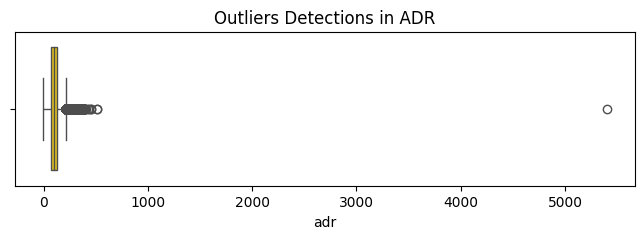

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,booking_changes,deposit_type,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
48515,City Hotel,1,35,2016,March,13,25,0,1,2,...,1,Non Refund,12.0,0,Transient,5400.0,0,0,Canceled,2016-02-19


In [13]:
# Check outliers in ADR
plt.figure(figsize=(8,2))
sns.boxplot(x=df['adr'], color='gold')
plt.title('Outliers Detections in ADR')
plt.show()

adr_outlier = df_clean[df_clean["adr"] > 5000]
display(adr_outlier.sample())

In [14]:
# Clean the ADR (ternyata ada 1 rows yg mengandung ADR negatif dan ada 1 rows outlier bernilai 5400)

df_clean = df_clean[
    (df_clean["adr"] > 0) & (df_clean["adr"] < 5000)
]

In [15]:
# Df_clean validation (Negative ADR and Outlier Removed)
df_clean[
    (df_clean["adr"] < 0) | (df_clean["adr"] > 5000)
]

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,booking_changes,deposit_type,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date


### 2.4.2 Zero Guest
Alasan
- Reservasi tanpa tamu tidak valid secara bisnis.

In [16]:
# Zero Guest Check

zero_guest = df_clean[
    (df_clean["adults"] == 0) &
    (df_clean["children"] == 0) &
    (df_clean["babies"] == 0)
]

zero_guest

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,booking_changes,deposit_type,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
31765,Resort Hotel,0,31,2016,December,53,27,2,8,0,...,3,No Deposit,0.0,0,Transient,28.00,1,0,Check-Out,2017-01-06
47444,City Hotel,0,48,2016,February,9,21,2,4,0,...,2,No Deposit,14.0,0,Transient-Party,56.27,0,0,Check-Out,2016-02-27
50701,City Hotel,0,122,2016,May,19,5,2,4,0,...,3,No Deposit,11.0,0,Transient,50.87,0,0,Check-Out,2016-05-11
50702,City Hotel,0,122,2016,May,19,5,2,4,0,...,3,No Deposit,11.0,0,Transient,50.87,0,0,Check-Out,2016-05-11
55809,City Hotel,0,256,2016,August,35,21,3,5,0,...,1,No Deposit,11.0,0,Transient,57.30,0,0,Check-Out,2016-08-29
78586,City Hotel,0,0,2015,November,49,30,1,2,0,...,2,No Deposit,0.0,0,Transient,6.00,0,0,Check-Out,2015-12-03
85931,City Hotel,0,9,2016,March,12,16,2,6,0,...,2,No Deposit,29.0,0,Transient,3.38,1,0,Check-Out,2016-03-24
88439,City Hotel,0,52,2016,April,18,30,2,4,0,...,2,No Deposit,14.0,0,Transient-Party,136.46,0,1,Check-Out,2016-05-06
92814,City Hotel,0,108,2016,July,28,5,2,5,0,...,0,No Deposit,89.0,0,Transient,77.53,0,0,Check-Out,2016-07-12
92962,City Hotel,0,55,2017,March,10,5,2,0,0,...,2,No Deposit,0.0,0,Transient,1.00,1,0,Check-Out,2017-03-07


In [17]:
# Zero Guest Check (ternyata ada 180 rows dimana guest kategori 0)

df_clean = df_clean[
    ~(
        (df_clean["adults"] == 0) &
        (df_clean["children"] == 0) &
        (df_clean["babies"] == 0)
    )
]

In [18]:
# Df_clean validation (Zero Guest Removed)
df_clean[
    (df_clean["adults"] == 0) &
    (df_clean["children"] == 0) &
    (df_clean["babies"] == 0)
]

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,booking_changes,deposit_type,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date


### 2.4.3 Consistency Summary
Dataset telah melalui pemeriksaan dasar terhadap nilai yang tidak logis
- Negative & Outlier ADR dihapus
- Zero Guest dihapus

In [19]:
# Validation

print(f"Rows    : {df_clean.shape[0]:,}")
print(f"Columns : {df_clean.shape[1]}")

Rows    : 117,398
Columns : 31


## 2.5 Leakage Handling
Tujuan
- Menghapus fitur yang mengandung informasi masa depan dan dapat menyebabkan data leakage.

In [20]:
# Leakage Verification

pd.crosstab(
    df_clean["reservation_status"],
    df_clean["is_canceled"]
)

# Interpretasi
# status canceled & no-show sudah pasti is_canceled(1)                -> tidak menginal di hotel / cancel                     -> tidak berpengaruh ke is_canceled
# status check-out sudah pasti is_canceled(0)                         -> menginap di hotel                                    -> tidak berpengaruh ke is_canceled
# karena reservation_status adalah leakage, maka reservation_status_date juga tidak diperlukan (hanya berisi tanggal status)  -> tidak berpengaruh ke is_canceled

is_canceled,0,1
reservation_status,,
Canceled,0,42829
Check-Out,73388,0
No-Show,0,1181


In [21]:
# Drop Leakage Features

df_clean.drop(
    columns=[
        "reservation_status",
        "reservation_status_date"
    ],
    inplace=True
)

In [22]:
# Validation column leakage sudah terhapus
df_clean.columns.tolist()

['hotel',
 'is_canceled',
 'lead_time',
 'arrival_date_year',
 'arrival_date_month',
 'arrival_date_week_number',
 'arrival_date_day_of_month',
 'stays_in_weekend_nights',
 'stays_in_week_nights',
 'adults',
 'children',
 'babies',
 'meal',
 'country',
 'market_segment',
 'distribution_channel',
 'is_repeated_guest',
 'previous_cancellations',
 'previous_bookings_not_canceled',
 'reserved_room_type',
 'assigned_room_type',
 'booking_changes',
 'deposit_type',
 'agent',
 'days_in_waiting_list',
 'customer_type',
 'adr',
 'required_car_parking_spaces',
 'total_of_special_requests']

## 2.6 Feature Preparation
Tujuan

Mempersiapkan feature yang:

- masih aman dibuat sebelum EDA,
- tidak menyebabkan leakage,
- membantu eksplorasi data,
- berpotensi berguna saat modeling.

Tahap ini belum Feature Engineering penuh, hanya membuat feature dasar yang hampir pasti berguna.

### 2.6.1 Total Stay
- Merepresentasikan total durasi menginap customer.

In [23]:
# Create Total Stay
df_clean["total_stay"] = (
    df_clean["stays_in_weekend_nights"] +
    df_clean["stays_in_week_nights"]
)

# Validation
df_clean[
    [
        "stays_in_weekend_nights",
        "stays_in_week_nights",
        "total_stay"
    ]
].head()

,stays_in_weekend_nights,stays_in_week_nights,total_stay
2,0,1,1
3,0,1,1
4,0,2,2
5,0,2,2
6,0,2,2


### 2.6.2 Total Guests
- Menggambarkan ukuran kelompok reservasi.

In [24]:
# Create Total Guests

df_clean["total_guests"] = (
    df_clean["adults"] +
    df_clean["children"] +
    df_clean["babies"]
)

df_clean[
    [
        "adults",
        "children",
        "babies",
        "total_guests"
    ]
].sample(5)

,adults,children,babies,total_guests
6961,2,0.0,0,2.0
94881,2,0.0,0,2.0
19661,2,0.0,0,2.0
99476,2,0.0,0,2.0
52911,2,0.0,0,2.0


### 2.6.3 Feature Preparation Review
- 2 feature baru

In [25]:
# New features statistic overview check

new_features = [
    "total_stay",
    "total_guests"
]

df_clean[new_features].describe().T

,count,mean,std,min,25%,50%,75%,max
total_stay,117398.0,3.456498,2.529264,1.0,2.0,3.0,4.0,69.0
total_guests,117398.0,1.973526,0.646541,1.0,2.0,2.0,2.0,12.0


## 2.7 Clean Dataset Summary

In [26]:
# Check cleaned dataset (df_clean)

df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 117398 entries, 2 to 119389
Data columns (total 31 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           117398 non-null  object 
 1   is_canceled                     117398 non-null  int64  
 2   lead_time                       117398 non-null  int64  
 3   arrival_date_year               117398 non-null  int64  
 4   arrival_date_month              117398 non-null  object 
 5   arrival_date_week_number        117398 non-null  int64  
 6   arrival_date_day_of_month       117398 non-null  int64  
 7   stays_in_weekend_nights         117398 non-null  int64  
 8   stays_in_week_nights            117398 non-null  int64  
 9   adults                          117398 non-null  int64  
 10  children                        117398 non-null  float64
 11  babies                          117398 non-null  int64  
 12  meal                 

Berdasarkan step Data Cleaning & Preparation:
- Membuat copy dataset untuk di manipulasi
- Memanipulasi missing value, duplicate value, dan logika anomali dalam dataset
- Menghapus column leakage
- Feature baru bisa di elaborasi lebih dalam lagi

Sekarang dataset sudah:
- bersih,
- bebas leakage,
- memiliki feature dasar tambahan,
- siap untuk analisis bisnis.

Selanjutnya pada Step 3 (EDA) akan fokus ke goals utama penilaian bootcamp:

- Analisis lead_time terhadap is_canceled
- Analisis deposit_type terhadap is_canceled
- Menemukan pola cancellation
- Menentukan feature paling berpengaruh untuk model F1 ≥ 82% tanpa kembali lagi ke tahap cleaning.

# **3. Exploratory Data Analysis (EDA)**

In [27]:
import matplotlib.patches as mpatches
import warnings; warnings.filterwarnings('ignore')

# ── Global Style ──────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#FAFAFA', 'axes.facecolor': '#FAFAFA',
    'axes.edgecolor':   '#CCCCCC', 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.color': '#EEEEEE', 'grid.linestyle': '-', 'grid.alpha': 0.8,
    'font.family': 'sans-serif', 'font.size': 11,
    'axes.titlesize': 13, 'axes.titleweight': 'bold',
    'axes.labelsize': 11, 'xtick.labelsize': 10, 'ytick.labelsize': 10,
})

# ── Semantic Palette ──────────────────────────────────────────────────────────
C_SAFE, C_MID, C_RISK = '#2E86AB', '#F4A261', '#E84855'

RISK_LEGEND = [mpatches.Patch(color=C_SAFE, label='Low (<25%)'),
               mpatches.Patch(color=C_MID,  label='Medium (25–45%)'),
               mpatches.Patch(color=C_RISK, label='High (>45%)')]

def risk_color(rate):
    return C_SAFE if rate < 25 else (C_MID if rate < 45 else C_RISK)

def annotate_bars(ax, fmt='{:.1f}%', offset=0.8, fontsize=10):
    for bar in ax.patches:
        h = bar.get_height()
        if h > 0:
            ax.text(bar.get_x() + bar.get_width()/2, h + offset,
                    fmt.format(h), ha='center', va='bottom',
                    fontsize=fontsize, fontweight='bold', color='#333')

def add_risk_legend(ax, loc='upper left'):
    ax.legend(handles=RISK_LEGEND, loc=loc, framealpha=0.9, fontsize=9,
              title='Risk Level', title_fontsize=9)

sns.set_theme(style="whitegrid")

print('✅ Style & helpers loaded.')

✅ Style & helpers loaded.


## 3.1 Cancellation Overview
Tujuan

>Memahami proporsi booking yang dibatalkan dan mengukur tingkat keparahan permasalahan cancellation pada hotel.

Hipotesis

>Jika tingkat cancellation cukup tinggi, maka diperlukan model prediksi untuk membantu mitigasi risiko operasional.

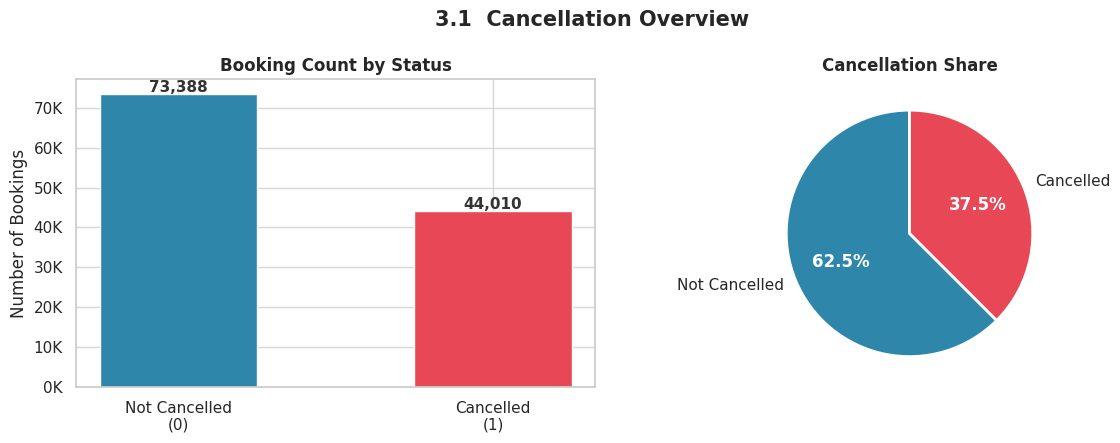

               proportion %
is_canceled                
Not Cancelled         62.51
Cancelled             37.49


In [28]:
# ── FIGURE 1 · Cancellation Overview ─────────────────────────────────────────
cancel_pct = (df_clean['is_canceled'].value_counts(normalize=True)
              .mul(100).round(2).rename({0:'Not Cancelled', 1:'Cancelled'}))
counts     = df_clean['is_canceled'].value_counts().rename({0:'Not Cancelled', 1:'Cancelled'})

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
fig.suptitle('3.1  Cancellation Overview', fontsize=15, fontweight='bold')

# Bar
bars = ax1.bar(counts.index, counts.values, color=[C_SAFE, C_RISK], width=0.5, edgecolor='white')
for bar, val in zip(bars, counts.values):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+500,
             f'{val:,}', ha='center', fontsize=11, fontweight='semibold', color='#333')
ax1.set_title('Booking Count by Status')
ax1.set_ylabel('Number of Bookings')
ax1.set_xticks([0,1]); ax1.set_xticklabels(['Not Cancelled\n(0)', 'Cancelled\n(1)'])
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'{x/1000:.0f}K'))

# Pie
wedges, texts, autotexts = ax2.pie(
    cancel_pct.values, labels=cancel_pct.index, colors=[C_SAFE, C_RISK],
    autopct='%1.1f%%', startangle=90, wedgeprops={'edgecolor':'white','linewidth':2})
for at in autotexts: at.set(fontsize=12, fontweight='bold', color='white')
ax2.set_title('Cancellation Share')

plt.tight_layout()
plt.savefig('fig1_cancellation_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print(cancel_pct.to_frame('proportion %'))

Observasi

>Sebanyak 37.49% booking dibatalkan, sedangkan 62.51% berhasil terealisasi. Proporsi ini menunjukkan bahwa cancellation merupakan kejadian yang cukup sering terjadi.

Insight Bisnis

>Hampir 4 dari 10 reservasi tidak berujung pada check-in sehingga berpotensi menyebabkan kehilangan pendapatan dan ketidakpastian okupansi hotel.

Implikasi terhadap Modeling

>Target layak digunakan untuk binary classification dan cukup representatif untuk membangun model prediksi cancellation.

## 3.2 Lead Time Analysis
Tujuan

>Menganalisis hubungan antara jarak waktu pemesanan dengan kemungkinan pembatalan reservasi.

Hipotesis

>Semakin jauh waktu booking dari tanggal kedatangan, semakin tinggi risiko cancellation.

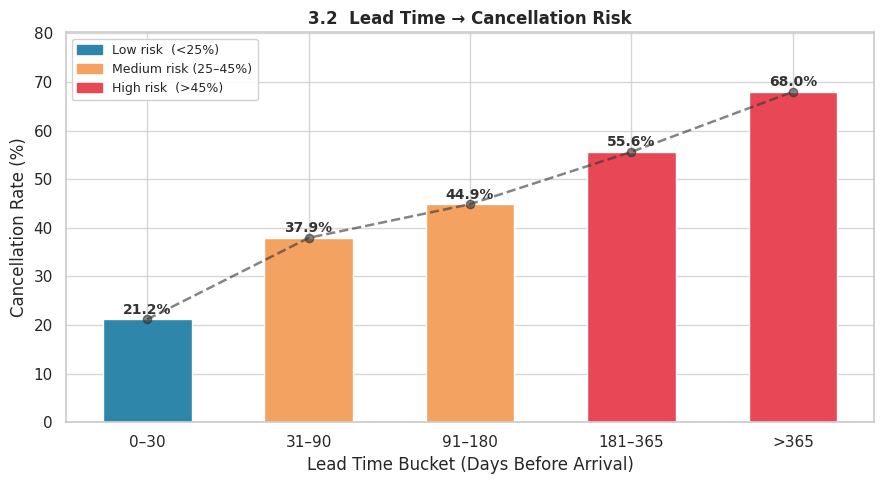

                  cancellation_rate %
lead_time_bucket                     
0–30                            21.17
31–90                           37.93
91–180                          44.87
181–365                         55.63
>365                            67.98


In [29]:
# ── FIGURE 2 · Lead Time Risk Curve ──────────────────────────────────────────
bins   = [0, 30, 90, 180, 365, 800]
labels = ['0–30', '31–90', '91–180', '181–365', '>365']

df_clean['lead_time_bucket'] = pd.cut(df_clean['lead_time'], bins=bins, labels=labels)
lead_rate = (
    df_clean.groupby('lead_time_bucket', observed=True)['is_canceled']
    .mean().mul(100).round(2)
)

fig, ax = plt.subplots(figsize=(9, 5))
colors = [risk_color(v) for v in lead_rate.values]
bars = ax.bar(lead_rate.index, lead_rate.values, color=colors, width=0.55, edgecolor='white')

# trend line
x = np.arange(len(lead_rate))
ax.plot(x, lead_rate.values, color='#333', linewidth=1.8, marker='o',
        markersize=6, zorder=5, linestyle='--', alpha=0.6)

annotate_bars(ax, offset=0.5)
ax.set_title('3.2  Lead Time → Cancellation Risk')
ax.set_xlabel('Lead Time Bucket (Days Before Arrival)')
ax.set_ylabel('Cancellation Rate (%)')
ax.set_ylim(0, lead_rate.max() * 1.18)

patches = [mpatches.Patch(color=C_SAFE,  label='Low risk  (<25%)'),
           mpatches.Patch(color=C_MID,   label='Medium risk (25–45%)'),
           mpatches.Patch(color=C_RISK,  label='High risk  (>45%)')]
ax.legend(handles=patches, loc='upper left', framealpha=0.9, fontsize=9)

plt.tight_layout()
plt.savefig('fig2_lead_time.png', dpi=150, bbox_inches='tight')
plt.show()
print(lead_rate.to_frame('cancellation_rate %'))

Observasi

>Cancellation rate meningkat secara konsisten dari 21.17% (0–30 hari) menjadi 67.98% (>365 hari). Pola ini menunjukkan hubungan positif yang sangat kuat antara lead time dan cancellation.

Insight Bisnis

>Customer yang memesan jauh hari memiliki tingkat ketidakpastian lebih tinggi sehingga lebih rentan mengubah atau membatalkan rencana perjalanan.

Implikasi terhadap Modeling

>lead_time merupakan salah satu kandidat feature terkuat dan dapat dikembangkan menjadi lead_time_bucket untuk segmentasi risiko.

## 3.3 Deposit Type Analysis
Tujuan

>Menganalisis pengaruh jenis deposit terhadap tingkat cancellation.

Hipotesis

>Semakin besar komitmen finansial pelanggan, semakin rendah kemungkinan booking dibatalkan.

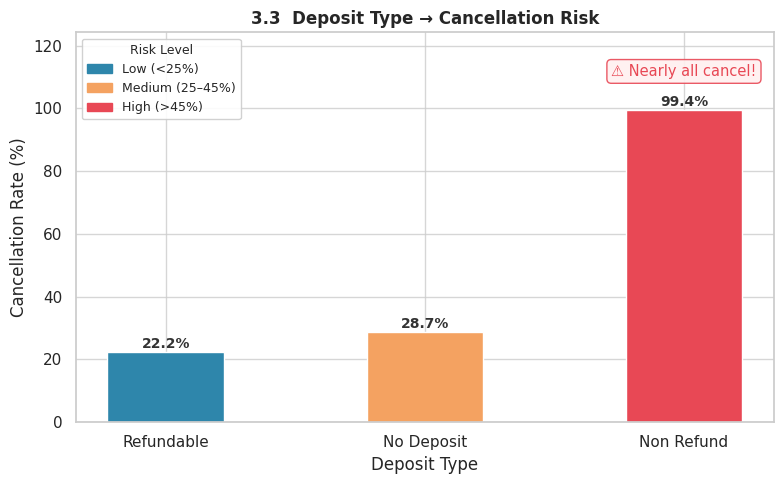

is_canceled       0      1
deposit_type              
Refundable    77.78  22.22
No Deposit    71.28  28.72
Non Refund     0.64  99.36


In [30]:
# ── FIGURE 3 · Deposit Commitment Analysis ────────────────────────────────────
dep_rate = (pd.crosstab(df_clean['deposit_type'], df_clean['is_canceled'],
                        normalize='index').mul(100).round(2).sort_values(1))

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(dep_rate.index, dep_rate[1].values,
              color=[risk_color(v) for v in dep_rate[1].values],
              width=0.45, edgecolor='white')

# Annotate % on top of each bar
annotate_bars(ax, offset=0.5)

# Insight label — placed above the Non Refund bar annotation
nr_val = dep_rate.loc['Non Refund', 1]
nr_x   = list(dep_rate.index).index('Non Refund')
ax.text(nr_x, nr_val + 10, '⚠ Nearly all cancel!',
        ha='center', va='bottom', fontsize=10.5, color=C_RISK,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#FFF0F0', edgecolor=C_RISK, alpha=0.9))

ax.set_title('3.3  Deposit Type → Cancellation Risk')
ax.set_xlabel('Deposit Type')
ax.set_ylabel('Cancellation Rate (%)')
ax.set_ylim(0, dep_rate[1].max() * 1.25)
add_risk_legend(ax, loc='upper left')

plt.tight_layout()
plt.savefig('fig3_deposit_type.png', dpi=150, bbox_inches='tight')
plt.show()
print(dep_rate)

Observasi

>Perbedaan cancellation rate antar jenis deposit sangat signifikan. Kategori deposit_type menunjukkan hubungan yang sangat kuat terhadap status cancellation.

Insight Bisnis

>Jenis deposit dapat digunakan sebagai indikator komitmen pelanggan terhadap reservasi yang telah dibuat.

Implikasi terhadap Modeling

>deposit_type wajib dipertahankan karena berpotensi menjadi predictor penting dalam model klasifikasi.

## 3.4 Customer Risk Factors
Tujuan

>Mengidentifikasi karakteristik pelanggan yang berkaitan dengan risiko cancellation.

Hipotesis

>Pelanggan loyal dan memiliki histori yang baik cenderung lebih jarang membatalkan reservasi.

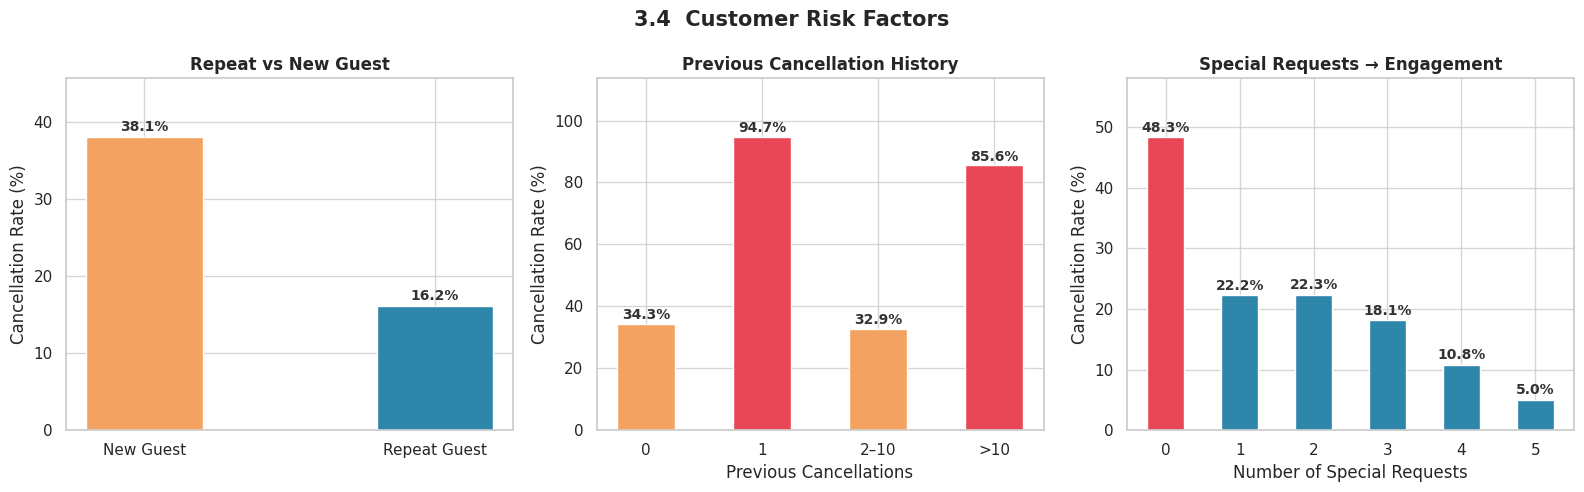

In [31]:
# ── FIGURE 4 · Customer Risk Dashboard ───────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('3.4  Customer Risk Factors', fontsize=15, fontweight='bold')

# ── Panel A: Repeated Guest ──
rg = (
    pd.crosstab(df_clean['is_repeated_guest'], df_clean['is_canceled'], normalize='index')
    .mul(100)[1]
    .rename({0: 'New Guest', 1: 'Repeat Guest'})
)
colors_rg = [risk_color(v) for v in rg.values]
axes[0].bar(rg.index, rg.values, color=colors_rg, width=0.4, edgecolor='white')
annotate_bars(axes[0], offset=0.4)
axes[0].set_title('Repeat vs New Guest')
axes[0].set_ylabel('Cancellation Rate (%)')
axes[0].set_ylim(0, rg.max() * 1.2)

# ── Panel B: Previous Cancellations ──
prev_cancel_map = {
    0: '0',
    **{i: '1' for i in [1]},
    **{i: '2–10' for i in range(2, 11)},
    **{i: '>10'  for i in range(11, 100)}
}
df_clean['prev_cancel_grp'] = df_clean['previous_cancellations'].map(
    lambda x: '>10' if x > 10 else ('2–10' if x >= 2 else str(x))
)
pc_order = ['0', '1', '2–10', '>10']
pc_rate = (
    df_clean.groupby('prev_cancel_grp')['is_canceled']
    .mean().mul(100).reindex(pc_order)
)
colors_pc = [risk_color(v) for v in pc_rate.values]
axes[1].bar(pc_rate.index, pc_rate.values, color=colors_pc, width=0.5, edgecolor='white')
annotate_bars(axes[1], offset=0.5)
axes[1].set_title('Previous Cancellation History')
axes[1].set_xlabel('Previous Cancellations')
axes[1].set_ylabel('Cancellation Rate (%)')
axes[1].set_ylim(0, pc_rate.max() * 1.2)

# ── Panel C: Special Requests ──
sr_rate = (
    df_clean.groupby('total_of_special_requests')['is_canceled']
    .mean().mul(100).head(6)
)
colors_sr = [risk_color(v) for v in sr_rate.values]
axes[2].bar(sr_rate.index.astype(str), sr_rate.values, color=colors_sr, width=0.5, edgecolor='white')
annotate_bars(axes[2], offset=0.4)
axes[2].set_title('Special Requests → Engagement')
axes[2].set_xlabel('Number of Special Requests')
axes[2].set_ylabel('Cancellation Rate (%)')
axes[2].set_ylim(0, sr_rate.max() * 1.2)

plt.tight_layout()
plt.savefig('fig4_customer_risk.png', dpi=150, bbox_inches='tight')
plt.show()

Observasi

>Repeated guest memiliki cancellation lebih rendah, sedangkan pelanggan dengan riwayat cancellation sebelumnya memiliki risiko pembatalan yang jauh lebih tinggi. Selain itu, semakin banyak special request yang diajukan, semakin rendah tingkat cancellation.

Insight Bisnis

>Perilaku historis pelanggan merupakan indikator penting untuk mengukur tingkat kepercayaan dan komitmen terhadap reservasi.

Implikasi terhadap Modeling

>s_repeated_guest, previous_cancellations, dan total_of_special_requests layak dipertahankan sebagai feature prediktif.

## 3.5 Booking Source Dashboard
Tujuan

>Menganalisis pengaruh sumber reservasi terhadap tingkat cancellation.

Hipotesis

>Setiap market segment dan distribution channel memiliki karakteristik risiko yang berbeda

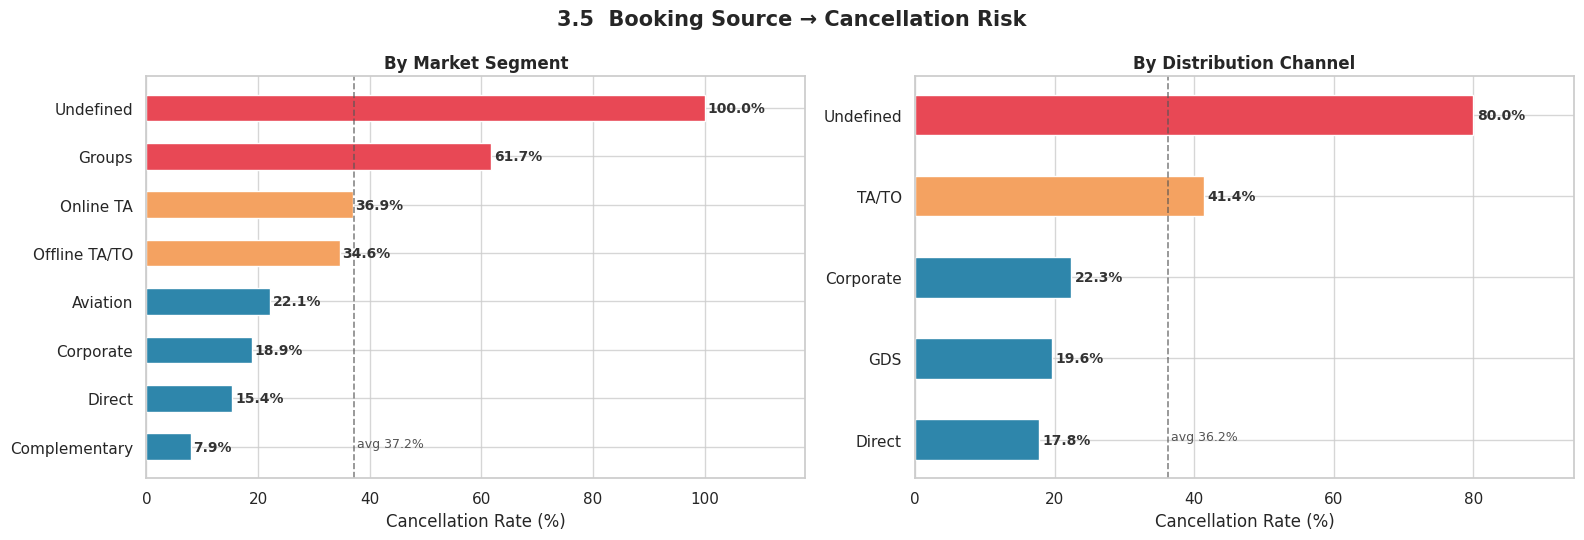

In [32]:
# ── FIGURE 5 · Booking Source Dashboard ──────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5.5))
fig.suptitle('3.5  Booking Source → Cancellation Risk', fontsize=15, fontweight='bold')

# ── Market Segment (horizontal, sorted) ──
ms_rate = (
    pd.crosstab(df_clean['market_segment'], df_clean['is_canceled'], normalize='index')
    .mul(100)[1].sort_values()
)
colors_ms = [risk_color(v) for v in ms_rate.values]
bars = ax1.barh(ms_rate.index, ms_rate.values, color=colors_ms, height=0.55, edgecolor='white')
for bar, val in zip(bars, ms_rate.values):
    ax1.text(val + 0.5, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}%', va='center', fontsize=10, fontweight='bold', color='#333')
ax1.set_title('By Market Segment')
ax1.set_xlabel('Cancellation Rate (%)')
ax1.set_xlim(0, ms_rate.max() * 1.18)
ax1.axvline(ms_rate.mean(), color='#555', linestyle='--', linewidth=1.2, alpha=0.7)
ax1.text(ms_rate.mean() + 0.5, 0, f'avg {ms_rate.mean():.1f}%', fontsize=9, color='#555')

# ── Distribution Channel ──
dc_rate = (
    pd.crosstab(df_clean['distribution_channel'], df_clean['is_canceled'], normalize='index')
    .mul(100)[1].sort_values()
)
colors_dc = [risk_color(v) for v in dc_rate.values]
bars2 = ax2.barh(dc_rate.index, dc_rate.values, color=colors_dc, height=0.5, edgecolor='white')
for bar, val in zip(bars2, dc_rate.values):
    ax2.text(val + 0.5, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}%', va='center', fontsize=10, fontweight='bold', color='#333')
ax2.set_title('By Distribution Channel')
ax2.set_xlabel('Cancellation Rate (%)')
ax2.set_xlim(0, dc_rate.max() * 1.18)
ax2.axvline(dc_rate.mean(), color='#555', linestyle='--', linewidth=1.2, alpha=0.7)
ax2.text(dc_rate.mean() + 0.5, 0, f'avg {dc_rate.mean():.1f}%', fontsize=9, color='#555')

plt.tight_layout()
plt.savefig('fig5_booking_source.png', dpi=150, bbox_inches='tight')
plt.show()

Observasi

>Terdapat perbedaan cancellation rate yang cukup besar antar market segment maupun distribution channel.

Insight Bisnis

>Risiko cancellation tidak hanya dipengaruhi oleh pelanggan, tetapi juga oleh asal kanal reservasi yang digunakan.

Implikasi terhadap Modeling

>market_segment dan distribution_channel perlu dipertahankan karena mengandung informasi perilaku booking yang relevan.

## 3.6 Revenue Risk Dashboard
Tujuan

>Menganalisis hubungan nilai reservasi dengan kemungkinan cancellation.

Hipotesis

>Booking dengan karakteristik nilai transaksi tertentu memiliki pola cancellation yang berbeda.

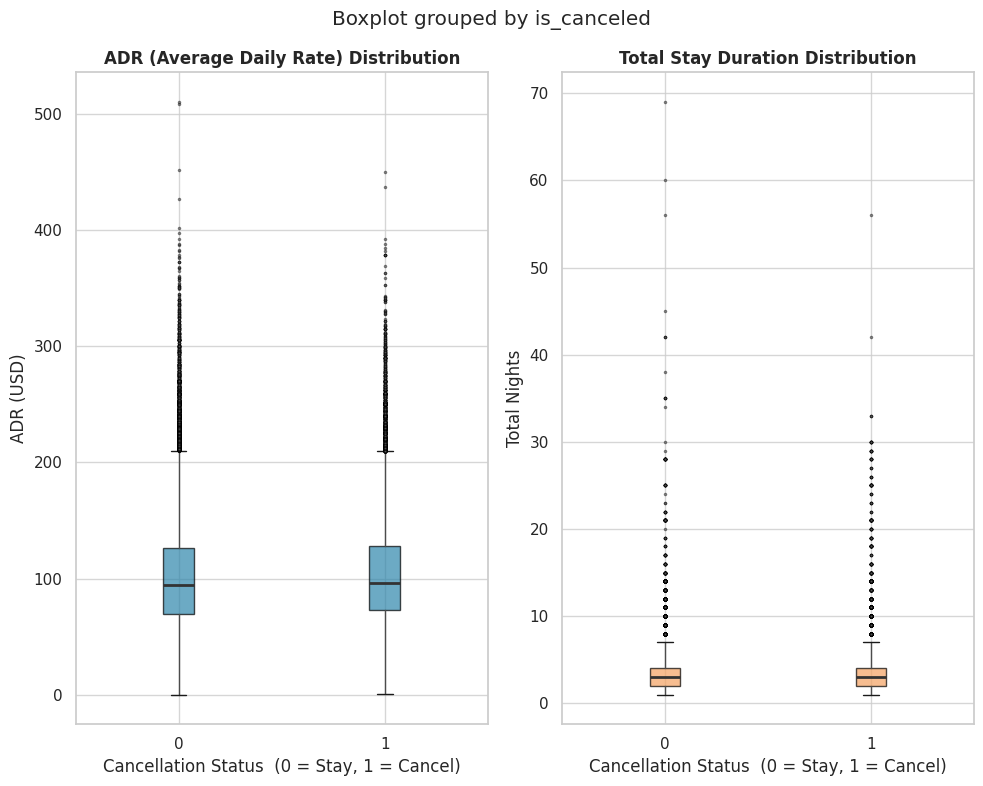


===Average Daily Rate distribution stat===


is_canceled,0,1
count,73388.0,44010.0
mean,102.4,105.4
std,47.3,45.7
min,0.3,0.5
25%,70.0,73.4
50%,94.5,96.3
75%,126.0,127.8
max,510.0,450.0



===Total Stay Duration distribution stat===


is_canceled,0,1
count,73388.0,44010.0
mean,3.4,3.5
std,2.5,2.5
min,1.0,1.0
25%,2.0,2.0
50%,3.0,3.0
75%,4.0,4.0
max,69.0,56.0


In [33]:
# ── FIGURE 6 · Revenue Risk Dashboard ────────────────────────────────────────
adr_stats    = df_clean.groupby('is_canceled')['adr'].median().rename({0:'Not Cancelled', 1:'Cancelled'})
stay_stats   = df_clean.groupby('is_canceled')['total_stay'].median().rename({0:'Not Cancelled', 1:'Cancelled'})

fig, axes = plt.subplots(1, 2, figsize=(10, 8))
fig.suptitle('3.6  Revenue Risk Dashboard', fontsize=15, fontweight='bold')

# ADR boxplot
bp1 = df_clean.boxplot(
    column='adr', by='is_canceled', ax=axes[0],
    patch_artist=True, notch=False,
    boxprops=dict(facecolor=C_SAFE, alpha=0.7),
    medianprops=dict(color='#333', linewidth=2),
    flierprops=dict(marker='.', markerfacecolor='#aaa', markersize=3, alpha=0.5)
)
axes[0].set_title('ADR (Average Daily Rate) Distribution')
axes[0].set_xlabel('Cancellation Status  (0 = Stay, 1 = Cancel)')
axes[0].set_ylabel('ADR (USD)')
fig.suptitle('3.6  Revenue Risk Dashboard', fontsize=15)  # restore after boxplot resets

# Total Stay boxplot
bp2 = df_clean.boxplot(
    column='total_stay', by='is_canceled', ax=axes[1],
    patch_artist=True, notch=False,
    boxprops=dict(facecolor=C_MID, alpha=0.7),
    medianprops=dict(color='#333', linewidth=2),
    flierprops=dict(marker='.', markerfacecolor='#aaa', markersize=3, alpha=0.5)
)
axes[1].set_title('Total Stay Duration Distribution')
axes[1].set_xlabel('Cancellation Status  (0 = Stay, 1 = Cancel)')
axes[1].set_ylabel('Total Nights')

plt.tight_layout()
plt.savefig('fig6_revenue_risk.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n===Average Daily Rate distribution stat===")
adr_deskriptif = df_clean.groupby('is_canceled')['adr'].describe().T.round(1)
display(adr_deskriptif)

print("\n===Total Stay Duration distribution stat===")
tsd_deskriptif = df_clean.groupby('is_canceled')['total_stay'].describe().T.round(1)
display(tsd_deskriptif)

## 3.7 Seasonal Risk Analysis
Tujuan

>Menguji apakah periode kedatangan tertentu memiliki tingkat cancellation yang berbeda.

Hipotesis

>Musim liburan dan periode ramai wisata memiliki tingkat cancellation yang lebih tinggi.

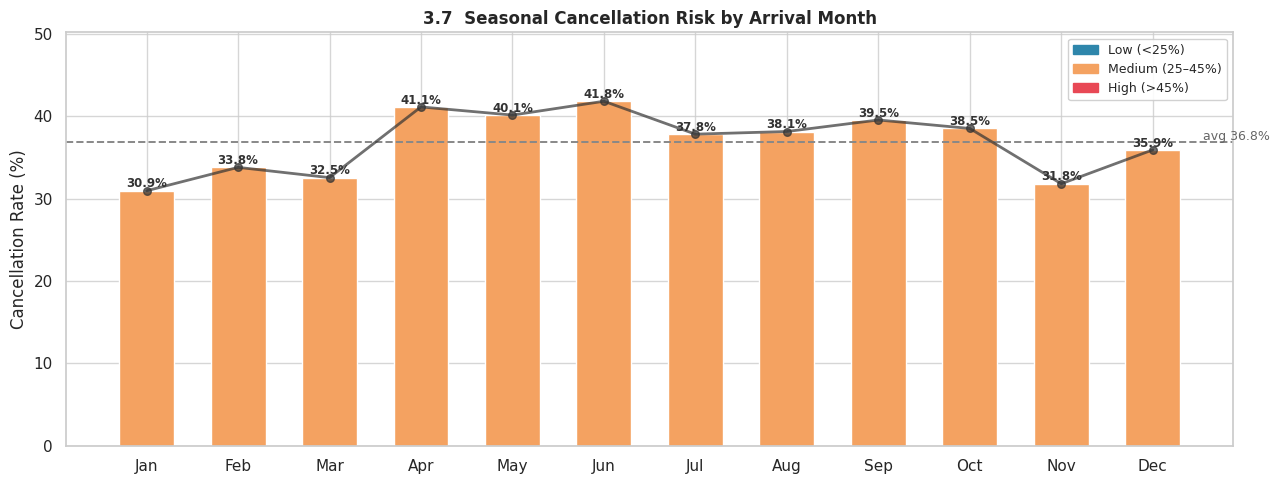

                    cancel_rate %
arrival_date_month               
January                 30.948276
February                33.792145
March                   32.544624
April                   41.124909
May                     40.136113
June                    41.813812
July                    37.820307
August                  38.141096
September               39.540052
October                 38.512215
November                31.801055
December                35.910339


In [34]:
# ── FIGURE 7 · Seasonal Risk Analysis ────────────────────────────────────────
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

month_rate = (
    pd.crosstab(df_clean['arrival_date_month'], df_clean['is_canceled'], normalize='index')
    .mul(100)[1]
    .reindex(month_order)
)

fig, ax = plt.subplots(figsize=(13, 5))
colors = [risk_color(v) for v in month_rate.values]
x = np.arange(len(month_order))

bars = ax.bar(x, month_rate.values, color=colors, width=0.6, edgecolor='white')

# line overlay
ax.plot(x, month_rate.values, color='#333', linewidth=2, marker='o',
        markersize=5.5, zorder=5, linestyle='-', alpha=0.7)

# value labels
for xi, val in zip(x, month_rate.values):
    ax.text(xi, val + 0.4, f'{val:.1f}%', ha='center', fontsize=8.5,
            fontweight='bold', color='#333')

# avg line
avg = month_rate.mean()
ax.axhline(avg, color='#888', linestyle='--', linewidth=1.4)
ax.text(11.55, avg + 0.3, f'avg {avg:.1f}%', fontsize=9, color='#666')

ax.set_title('3.7  Seasonal Cancellation Risk by Arrival Month')
ax.set_ylabel('Cancellation Rate (%)')
ax.set_xticks(x)
ax.set_xticklabels([m[:3] for m in month_order])
ax.set_ylim(0, month_rate.max() * 1.2)

patches = [mpatches.Patch(color=C_SAFE, label='Low (<25%)'),
           mpatches.Patch(color=C_MID,  label='Medium (25–45%)'),
           mpatches.Patch(color=C_RISK, label='High (>45%)')]
ax.legend(handles=patches, loc='upper right', framealpha=0.9, fontsize=9)

plt.tight_layout()
plt.savefig('fig7_seasonal.png', dpi=150, bbox_inches='tight')
plt.show()
print(month_rate.to_frame('cancel_rate %'))

Observasi

>Cancellation rate berfluktuasi sepanjang tahun dan mencapai nilai tertinggi pada periode April–Juni.

Insight Bisnis

>Terdapat indikasi pengaruh faktor musiman terhadap perilaku pembatalan reservasi pelanggan.

Implikasi terhadap Modeling

>Feature berbasis waktu seperti arrival_date_month dapat dikembangkan menjadi feature musiman (seasonal feature) pada tahap feature engineering.

## 3.8 EDA Summary

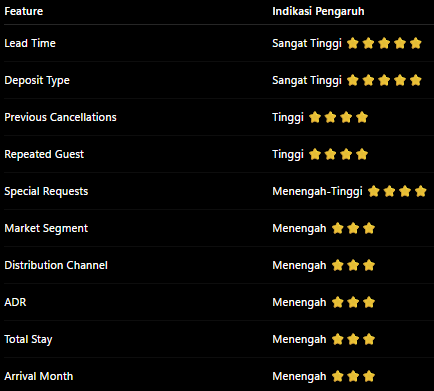

Berdasarkan hasil Exploratory Data Analysis (EDA), beberapa faktor utama yang berhubungan dengan pembatalan reservasi berhasil diidentifikasi:

- Lead Time memiliki hubungan paling kuat dengan cancellation.
- Deposit Type menunjukkan pengaruh signifikan terhadap risiko pembatalan.
- Riwayat cancellation, status repeated guest, dan special request berkontribusi terhadap perilaku pelanggan.
- Market segment dan distribution channel memiliki tingkat risiko yang berbeda.
- Terdapat indikasi pengaruh faktor musiman terhadap cancellation.

Dataset kini telah:

- bersih dan siap digunakan untuk modeling,
- bebas dari leakage feature,
- memiliki kandidat feature penting hasil EDA,
- menghasilkan insight yang mendukung objective bootcamp.

Langkah selanjutnya adalah Step 4 (Modeling & Evaluation), dengan fokus pada:

- Train-Test Split.
- Feature Encoding & Preprocessing.
- Baseline Model Development.
- Model Comparison.
- Evaluasi menggunakan F1-Score.
- Mencapai target F1-Score ≥ 82%.

Dengan selesainya tahap EDA, proses dapat dilanjutkan ke tahap machine learning untuk membangun model prediksi hotel booking cancellation yang akurat dan stabil.

# 4. Modeling & Evaluation

## 4.1 Feature Selection
Tujuan

- Menentukan feature yang akan digunakan dalam proses machine learning berdasarkan hasil data cleaning, leakage handling, dan temuan dari tahap EDA.

Strategi Pemilihan Feature

 >Pada tahap EDA ditemukan beberapa feature yang memiliki hubungan kuat terhadap target is_canceled. Feature tersebut diprioritaskan untuk digunakan dalam proses modeling.

 >Feature yang telah teridentifikasi sebagai leakage sebelumnya tidak akan digunakan kembali karena berpotensi memberikan informasi yang tidak tersedia saat prediksi dilakukan.

In [35]:
# Feature korelasi cancellation paling kuat
core_features = [
    'lead_time',
    'deposit_type',
    'previous_cancellations',
    'is_repeated_guest',
    'total_of_special_requests'
]

# Feature dipertahankan karena brepotensi meningkatkan performa model
supporting_features = [
    'hotel',
    'arrival_date_month',
    'stays_in_weekend_nights',
    'stays_in_week_nights',
    'adults',
    'children',
    'babies',
    'country',
    'market_segment',
    'distribution_channel',
    'reserved_room_type',
    'assigned_room_type',
    'booking_changes',
    'agent',
    'customer_type',
    'adr',
    'required_car_parking_spaces',
    'total_stay' # Feature engineering tahap cleaning
    'total_guest' # Feature engineering tahap cleaning
]

# Feature yang sudah dihapus pada tahap cleaning
excluded_features = [
    'reservation_status',
    'reservation_status_date'
]

df_clean.sample(5)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,total_stay,total_guests,lead_time_bucket,prev_cancel_grp
102324,City Hotel,0,21,2016,November,48,21,1,5,1,...,85.0,0,Transient,63.75,0,0,6,1.0,0–30,0
18309,Resort Hotel,0,2,2015,November,47,16,1,0,2,...,240.0,0,Transient,43.20,0,1,1,2.0,0–30,0
81218,City Hotel,0,16,2015,December,49,4,1,2,2,...,9.0,0,Contract,113.67,0,1,3,2.0,0–30,0
39106,Resort Hotel,0,22,2017,August,31,5,2,1,2,...,508.0,0,Transient-Party,188.60,0,1,3,2.0,0–30,0
105960,City Hotel,0,70,2017,February,7,15,0,4,2,...,0.0,0,Transient-Party,78.00,0,0,4,2.0,31–90,0


In [36]:
# FEATURE SELECTION

print(f"Dataset Shape : {df_clean.shape}")

print("\nTarget:")
print("is_canceled")

Dataset Shape : (117398, 33)

Target:
is_canceled


Ringkasan

>Dataset yang digunakan untuk modeling merupakan hasil akhir dari proses cleaning dan EDA sehingga seluruh feature yang tersisa dianggap valid untuk digunakan dalam proses machine learning.

## 4.2 ML Dataset Preparation & Train-Test Split
Tujuan

- Mempersiapkan dataset machine learning dengan memisahkan feature dan target serta membagi data menjadi data training dan testing.

Pembagian data dilakukan menggunakan rasio:

>80%         -> Training Data

>20%         -> Testing Data

>stratify=y  -> digunakan untuk menjaga proporsi kelas cancellation tetap konsisten pada data train dan test.

Dengan pendekatan ini evaluasi model dapat merepresentasikan kondisi data yang sebenarnya.

In [37]:
# FEATURE & TARGET

X = df_clean.drop(columns=['is_canceled'])

y = df_clean['is_canceled']

print("Feature Shape :", X.shape)
print("Target Shape  :", y.shape)

Feature Shape : (117398, 32)
Target Shape  : (117398,)


In [38]:
# TRAIN TEST SPLIT

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("X Train :", X_train.shape)
print("X Test  :", X_test.shape)

print("y Train :", y_train.shape)
print("y Test  :", y_test.shape)

X Train : (93918, 32)
X Test  : (23480, 32)
y Train : (93918,)
y Test  : (23480,)


In [39]:
# TARGET DISTRIBUTION CHECK

print("Original Distribution")
print(y.value_counts(normalize=True))

print("\nTrain Distribution")
print(y_train.value_counts(normalize=True))

print("\nTest Distribution")
print(y_test.value_counts(normalize=True))

Original Distribution
is_canceled
0    0.625121
1    0.374879
Name: proportion, dtype: float64

Train Distribution
is_canceled
0    0.62512
1    0.37488
Name: proportion, dtype: float64

Test Distribution
is_canceled
0    0.625128
1    0.374872
Name: proportion, dtype: float64


Ringkasan

>Dataset machine learning berhasil dipersiapkan dan dibagi menjadi data training serta testing dengan distribusi target yang tetap terjaga.

>Data training akan digunakan untuk membangun model, sedangkan data testing akan digunakan sebagai evaluasi akhir performa model.


## 4.3 Preprocessing Pipeline
Tujuan

- Menyiapkan transformasi data yang diperlukan sebelum model machine learning dilatih.

Strategi

>Dataset terdiri dari kombinasi feature numerik dan kategorikal sehingga diperlukan pendekatan preprocessing yang berbeda untuk masing-masing tipe data.

>Feature numerik akan diteruskan tanpa encoding.
Feature kategorikal akan diubah menggunakan One Hot Encoding.
Seluruh transformasi digabung menggunakan ColumnTransformer.

>Pendekatan pipeline digunakan agar proses training dan inference berjalan secara konsisten.

In [40]:
# FEATURE TYPE SEPARATION

categorical_features = X_train.select_dtypes(
    include=['object', 'category']
).columns.tolist()

numerical_features = X_train.select_dtypes(
    exclude=['object', 'category']
).columns.tolist()

print("Categorical :", len(categorical_features))
print("Numerical   :", len(numerical_features))

Categorical : 12
Numerical   : 20


In [41]:
# PREPROCESSOR
# Disini encoding (OneHotEncoder) tidak dilakukan manual seperti yg diajarkan pada bootcamp karena kolom kategorical ada 12, masa satu2
# Tetapi meggunakan fitur preprocessing dari library scikit yaitu OneHotEncoder saja

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        (
            'cat',
            OneHotEncoder(
                handle_unknown='ignore'
            ),
            categorical_features
        )
    ],
    remainder='passthrough'
)

preprocessor

ColumnTransformer(remainder='passthrough',
                  transformers=[('cat', OneHotEncoder(handle_unknown='ignore'),
                                 ['hotel', 'arrival_date_month', 'meal',
                                  'country', 'market_segment',
                                  'distribution_channel', 'reserved_room_type',
                                  'assigned_room_type', 'deposit_type',
                                  'customer_type', 'lead_time_bucket',
                                  'prev_cancel_grp'])])

Ringkasan

>Pipeline preprocessing telah disiapkan untuk menangani seluruh feature kategorikal dan numerik secara otomatis sehingga dapat digunakan kembali pada berbagai algoritma machine learning.

## 4.4 Baseline Model Development
Tujuan

- Membandingkan beberapa algoritma klasifikasi untuk menentukan model yang paling sesuai dalam memprediksi hotel booking cancellation.

Strategi Pemilihan Model

Dataset hotel booking cancellation memiliki karakteristik:
- kombinasi feature numerik dan kategorikal,
- hubungan non-linear antar variabel,
- jumlah observasi yang besar (>119.000 baris),
- target berupa binary classification,
- objective utama menggunakan F1-Score.

Berdasarkan karakteristik tersebut, dipilih tiga model yang mewakili pendekatan machine learning yang berbeda.


---


| Model               | Alasan Pemilihan                                                                                                                     |
| ------------------- | ------------------------------------------------------------------------------------------------------------------------------------ |
| Logistic Regression | Baseline linear classifier untuk mengukur performa minimum yang dapat dicapai model sederhana                                        |
| Random Forest       | Ensemble tree-based yang mampu menangkap hubungan non-linear dan interaksi antar feature                                             |
| XGBoost             | Gradient boosting yang dikenal memiliki performa tinggi pada dataset tabular dan sering menjadi benchmark kompetisi machine learning |


---


Dengan membandingkan ketiga model tersebut, dapat diketahui apakah pola cancellation cukup sederhana untuk dipelajari model linear atau membutuhkan model ensemble yang lebih kompleks.

Evaluation Metric

- Metric utama yang digunakan adalah F1-Score.

F1-Score dipilih karena:

- menggabungkan Precision dan Recall,
- lebih representatif dibanding Accuracy pada kasus klasifikasi risiko,
- sesuai dengan objective bootcamp (F1 ≥ 82%).

In [42]:
# IMPORT MODEL
!pip install xgboost # tidak ada library xgboost dalam google colab (runtime v5e-1 TPU)

import xgboost as xgb

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    accuracy_score
)

In [43]:
# BASELINE MODELS

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        random_state=42,
        eval_metric='logloss'
    )
}

In [44]:
# TRAIN & EVALUATE BASELINE

baseline_results = []

for name, model in models.items():

    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    baseline_results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred)
    })

baseline_results = pd.DataFrame(
    baseline_results
)

baseline_results.sort_values(
    by='F1 Score',
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score
1,Random Forest,0.896082,0.901743,0.811179,0.854067
2,XGBoost,0.880877,0.859194,0.815951,0.837014
0,Logistic Regression,0.814055,0.815595,0.651216,0.724195


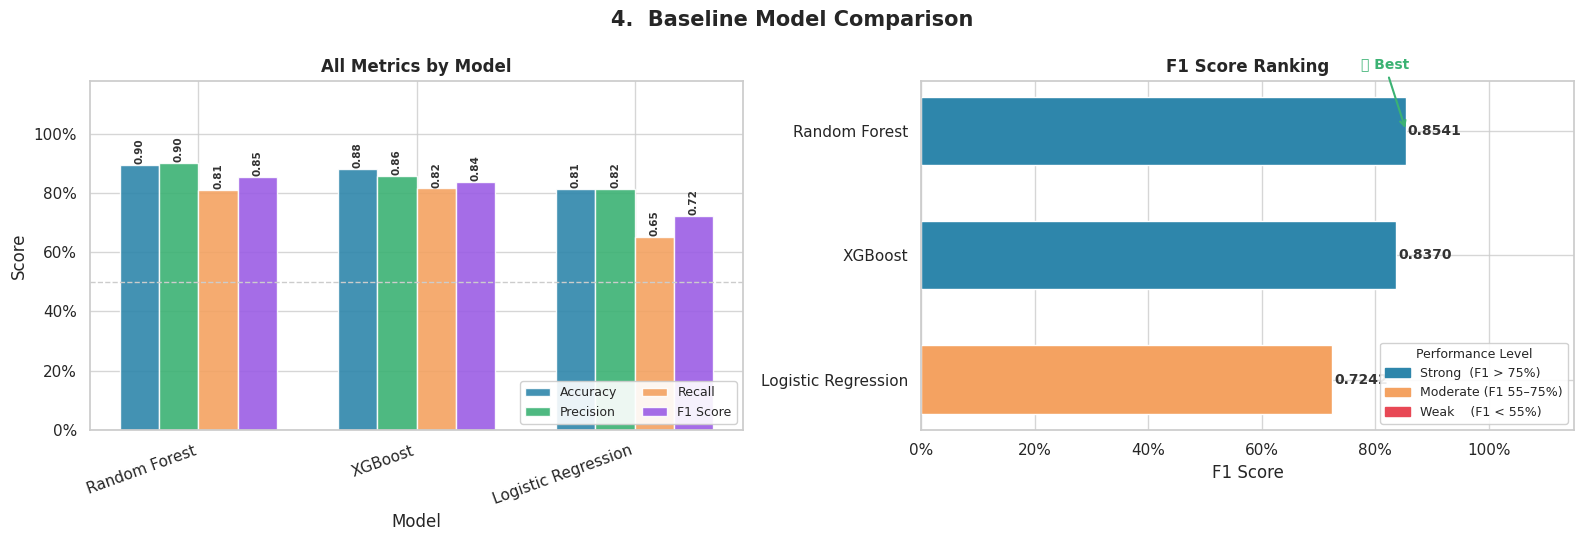

              Model  Accuracy  Precision   Recall  F1 Score
      Random Forest  0.896082   0.901743 0.811179  0.854067
            XGBoost  0.880877   0.859194 0.815951  0.837014
Logistic Regression  0.814055   0.815595 0.651216  0.724195


In [45]:
# ── FIGURE 8 · Baseline Model Comparison ─────────────────────────────────────
# baseline_results DataFrame already exists from training cell
# C_SAFE, C_MID, C_RISK, add_risk_legend, RISK_LEGEND defined in setup

import matplotlib.ticker as mticker

df_res = baseline_results.sort_values('F1 Score', ascending=False).reset_index(drop=True)
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
METRIC_COLORS = ['#2E86AB', '#3BB273', '#F4A261', '#9B5DE5']

n_models  = len(df_res)
n_metrics = len(metrics)
x         = np.arange(n_models)
bar_w     = 0.18

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))
fig.suptitle('4.  Baseline Model Comparison', fontsize=15, fontweight='bold')

# ── Panel A: Grouped Bar — all metrics per model ──────────────────────────────
ax = axes[0]
for i, (metric, color) in enumerate(zip(metrics, METRIC_COLORS)):
    offsets = x + (i - n_metrics/2 + 0.5) * bar_w
    bars = ax.bar(offsets, df_res[metric].values, width=bar_w,
                  color=color, edgecolor='white', label=metric, alpha=0.9)
    for bar, val in zip(bars, df_res[metric].values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f'{val:.2f}', ha='center', va='bottom', fontsize=7.5,
                fontweight='bold', color='#333', rotation=90)

ax.set_title('All Metrics by Model')
ax.set_ylabel('Score')
ax.set_xlabel('Model')
ax.set_xticks(x)
ax.set_xticklabels(df_res['Model'], rotation=20, ha='right')
ax.set_ylim(0, 1.18)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax.axhline(0.5, color='#ccc', lw=1, ls='--')
ax.legend(loc='lower right', fontsize=9, framealpha=0.9, ncol=2)

# ── Panel B: Horizontal bar — F1 Score ranking ───────────────────────────────
ax2 = axes[1]
df_sorted = df_res.sort_values('F1 Score')  # ascending for hbar (best at top)

bar_colors = [risk_color((1 - v) * 100) for v in df_sorted['F1 Score'].values]
hbars = ax2.barh(range(len(df_sorted)), df_sorted['F1 Score'].values,
                 color=bar_colors, height=0.55, edgecolor='white')

for bar, val in zip(hbars, df_sorted['F1 Score'].values):
    ax2.text(val + 0.003, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=10, fontweight='bold', color='#333')

# Best model callout
best_f1  = df_sorted['F1 Score'].max()
best_idx = df_sorted['F1 Score'].values.tolist().index(best_f1)
ax2.annotate('🏆 Best', xy=(best_f1, best_idx), xytext=(best_f1 - 0.08, best_idx + 0.5),
             fontsize=10, fontweight='bold', color='#3BB273',
             arrowprops=dict(arrowstyle='->', color='#3BB273', lw=1.5))

ax2.set_title('F1 Score Ranking')
ax2.set_xlabel('F1 Score')
ax2.set_yticks(range(len(df_sorted)))
ax2.set_yticklabels(df_sorted['Model'])
ax2.set_xlim(0, 1.15)
ax2.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))

# Risk legend repurposed: map to model performance
perf_legend = [
    mpatches.Patch(color=C_SAFE,  label='Strong  (F1 > 75%)'),
    mpatches.Patch(color=C_MID,   label='Moderate (F1 55–75%)'),
    mpatches.Patch(color=C_RISK,  label='Weak    (F1 < 55%)'),
]
ax2.legend(handles=perf_legend, loc='lower right', framealpha=0.9, fontsize=9,
           title='Performance Level', title_fontsize=9)

plt.tight_layout()
plt.savefig('fig8_baseline_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(df_res[['Model'] + metrics].to_string(index=False))

Hasil Perbandingan Baseline

| Model               | Accuracy | Precision | Recall | F1 Score   |
| ------------------- | -------- | --------- | ------ | ---------- |
| Random Forest       | 89.61%   | 90.17%    | 81.12% | **85.41%** |
| XGBoost             | 88.09%   | 85.91%    | 81.60% | **83.70%** |
| Logistic Regression | 81.41%   | 81.56%    | 65.12% | **72.42%** |

Observasi
- Random Forest menghasilkan performa terbaik pada seluruh metrik evaluasi.
XGBoost menunjukkan performa yang kompetitif namun masih berada di bawah Random Forest.

- Logistic Regression memiliki performa paling rendah, menunjukkan bahwa pola cancellation tidak sepenuhnya linear.

- Perbedaan performa antara model linear dan tree-based mengindikasikan adanya hubungan non-linear antar feature yang lebih efektif ditangkap oleh model ensemble.

Insight Bisnis

>Hasil ini menunjukkan bahwa keputusan pembatalan reservasi tidak dipengaruhi oleh satu faktor secara sederhana, melainkan merupakan kombinasi berbagai karakteristik pelanggan, pola reservasi, dan faktor operasional hotel.

>Model berbasis ensemble seperti Random Forest lebih mampu menangkap kompleksitas tersebut dibandingkan model linear.

Berdasarkan F1-Score sebagai metric utama proyek:
>Random Forest → Champion Baseline Model = F1-Score = 85.41%

Random Forest dipilih sebagai model final karena menghasilkan performa terbaik pada seluruh metrik evaluasi.

Kesimpulan

> Tahap baseline berhasil menunjukkan bahwa Random Forest merupakan kandidat model terbaik untuk memprediksi hotel booking cancellation.

> Oleh karena itu proses selanjutnya akan difokuskan pada optimasi Random Forest untuk memperoleh performa yang lebih stabil dan optimal.

## 4.5 Final Model Evaluation
Tujuan

- Tahap ini bertujuan mengevaluasi performa model terbaik pada data testing yang belum pernah digunakan selama proses pelatihan.

Evaluasi dilakukan menggunakan
- Classification Report Interpretation
- Confusion Matrix Interpretation
- Evaluation Strategy (metrik klasifikasi yaitu Accuracy, Precision, Recall, dan F1-Score)
- Business Insight

Fokus utama proyek ini adalah F1-Score karena metrik tersebut mampu menyeimbangkan kemampuan model dalam mendeteksi cancellation dan meminimalkan kesalahan prediksi.

### 4.5.1 Classification Report Interpretation

Model menunjukkan performa yang baik pada kedua kelas target.
>Untuk kelas cancellation (1), model mencapai Precision sebesar 86% dan Recall sebesar 82%, menunjukkan bahwa sebagian besar reservasi yang berpotensi dibatalkan berhasil teridentifikasi dengan baik.

>Perbedaan antara Precision dan Recall menunjukkan bahwa model masih melewatkan sebagian kecil kasus cancellation, namun secara keseluruhan telah menghasilkan F1-Score sebesar 84% pada kelas cancellation.

Nilai ini cukup baik untuk mendukung kebutuhan prediksi risiko pembatalan reservasi.

In [55]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.89      0.92      0.91     14678
           1       0.86      0.82      0.84      8802

    accuracy                           0.88     23480
   macro avg       0.88      0.87      0.87     23480
weighted avg       0.88      0.88      0.88     23480



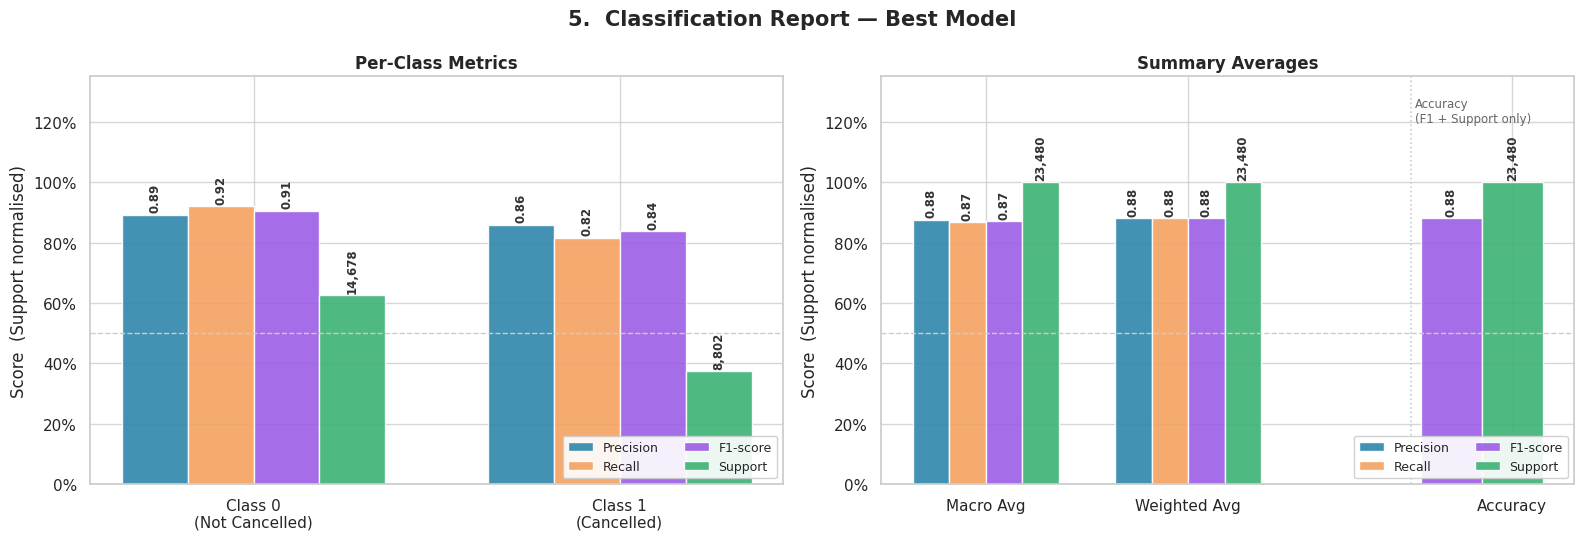

In [65]:
from sklearn.metrics import classification_report
import matplotlib.ticker as mticker

report = classification_report(y_test, y_pred, output_dict=True)
df_rpt = pd.DataFrame(report).T

# Palette — consistent with baseline
M_COLOR = {'precision': '#2E86AB', 'recall': '#F4A261',
           'f1-score':  '#9B5DE5', 'support': '#3BB273'}

total_support = int(df_rpt.loc['weighted avg', 'support'])
sup_norm      = lambda v: v / total_support   # normalise support to 0-1 scale

bar_w = 0.18

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5.5))
fig.suptitle('5.  Classification Report — Best Model', fontsize=15, fontweight='bold')

# ── Chart 1 · Class 0 & 1 — Precision / Recall / F1 / Support ────────────────
rows1    = ['0', '1']
xlbls1   = ['Class 0\n(Not Cancelled)', 'Class 1\n(Cancelled)']
cols1    = ['precision', 'recall', 'f1-score', 'support']
x1       = np.arange(len(rows1))

for i, col in enumerate(cols1):
    raw  = df_rpt.loc[rows1, col].astype(float).values
    norm = np.where(col == 'support', [sup_norm(v) for v in raw], raw)
    offsets = x1 + (i - len(cols1)/2 + 0.5) * bar_w
    bars = ax1.bar(offsets, norm, width=bar_w,
                   color=M_COLOR[col], edgecolor='white', label=col.capitalize(), alpha=0.9)
    for bar, val in zip(bars, raw):
        lbl = f'{int(val):,}' if col == 'support' else f'{val:.2f}'
        ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.008,
                 lbl, ha='center', va='bottom', fontsize=8.5,
                 fontweight='bold', color='#333', rotation=90)

ax1.set(title='Per-Class Metrics', ylabel='Score  (Support normalised)',
        xticks=x1, xticklabels=xlbls1, ylim=(0, 1.35))
ax1.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax1.axhline(0.5, color='#ccc', lw=1, ls='--')
ax1.legend(loc='lower right', fontsize=9, framealpha=0.9, ncol=2)

# ── Chart 2 · Macro Avg / Weighted Avg (P+R+F1+Sup)  |  Accuracy (F1+Sup only) ──
# Groups: Macro Avg, Weighted Avg → 4 bars each
#         Accuracy               → 2 bars only (f1-score + support), placed last, wider

rows_avg = ['macro avg', 'weighted avg']
cols_avg = ['precision', 'recall', 'f1-score', 'support']
x2       = np.arange(len(rows_avg))   # positions 0, 1
x_acc    = np.array([2.6])            # accuracy shifted right, gap = 0.6
bar_w_avg = 0.18
bar_w_acc = 0.30                      # wider for accuracy

# Draw Macro & Weighted Avg — 4 bars each
for i, col in enumerate(cols_avg):
    raw  = df_rpt.loc[rows_avg, col].astype(float).values
    norm = np.where(col == 'support', [sup_norm(v) for v in raw], raw)
    offsets = x2 + (i - len(cols_avg)/2 + 0.5) * bar_w_avg
    bars = ax2.bar(offsets, norm, width=bar_w_avg,
                   color=M_COLOR[col], edgecolor='white', alpha=0.9,
                   label=col.capitalize() if i < len(cols_avg) else '_')
    for bar, val in zip(bars, raw):
        lbl = f'{int(val):,}' if col == 'support' else f'{val:.2f}'
        ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.008,
                 lbl, ha='center', va='bottom', fontsize=8.5,
                 fontweight='bold', color='#333', rotation=90)

# Draw Accuracy — F1 + Support only, wider bars, side by side
acc_f1  = float(df_rpt.loc['accuracy', 'f1-score'])
acc_sup = total_support   # always full support

for j, (col, raw_val) in enumerate([('f1-score', acc_f1), ('support', acc_sup)]):
    norm_val = sup_norm(raw_val) if col == 'support' else raw_val
    offset   = x_acc + (j - 1) * bar_w_acc
    bar = ax2.bar(offset, norm_val, width=bar_w_acc,
                  color=M_COLOR[col], edgecolor='white', alpha=0.9)
    lbl = f'{int(raw_val):,}' if col == 'support' else f'{raw_val:.2f}'
    ax2.text(offset[0], norm_val + 0.008, lbl,
             ha='center', va='bottom', fontsize=8.5,
             fontweight='bold', color='#333', rotation=90)

# X-axis ticks
ax2.set_xticks(list(x2) + [float(x_acc)])
ax2.set_xticklabels(['Macro Avg', 'Weighted Avg', 'Accuracy'])
ax2.set(title='Summary Averages', ylabel='Score  (Support normalised)', ylim=(0, 1.35))
ax2.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax2.axhline(0.5, color='#ccc', lw=1, ls='--')

# Divider line between avg groups and accuracy
ax2.axvline(2.1, color='#ccc', lw=1.2, ls=':')
ax2.text(2.12, 1.28, 'Accuracy\n(F1 + Support only)', fontsize=8.5,
         color='#666', va='top')

ax2.legend(loc='lower right', fontsize=9, framealpha=0.9, ncol=2)

plt.tight_layout()
plt.savefig('fig10_clf_report.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.5.2 Confusion Matrix Interpretation

Confusion Matrix memberikan gambaran mengenai jumlah prediksi yang benar dan salah pada masing-masing kelas.

>Sebagian besar observasi berhasil diklasifikasikan dengan benar baik untuk kelas cancellation maupun non-cancellation.

>Jumlah False Positive dan False Negative relatif rendah dibandingkan total observasi, menunjukkan bahwa model memiliki kemampuan prediksi yang stabil.

Dari perspektif bisnis, hasil ini penting karena kesalahan prediksi yang terlalu tinggi dapat menyebabkan keputusan operasional yang kurang optimal, seperti salah memperkirakan tingkat okupansi kamar atau memberikan perlakuan yang tidak sesuai kepada pelanggan.

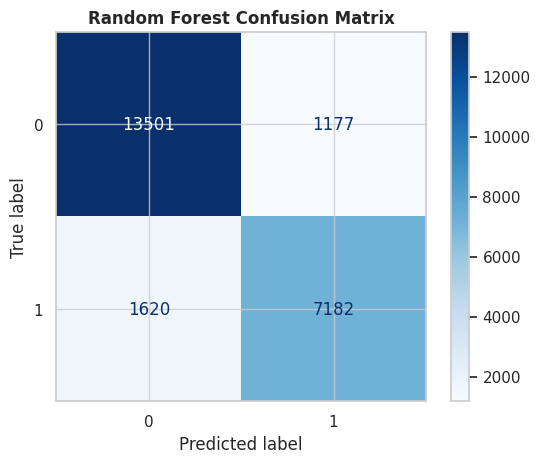

In [49]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap='Blues'
)

plt.title("Random Forest Confusion Matrix")
plt.show()

# Confusion Matrix Interpretation
# - Sebagian besar reservasi berhasil diklasifikasikan dengan benar baik pada kelas cancellation maupun non-cancellation.
# - Jumlah False Positive dan False Negative relatif rendah dibandingkan total observasi, menunjukkan bahwa model memiliki kemampuan prediksi yang stabil dan dapat digunakan sebagai sistem pendukung keputusan operasional hotel.

### 4.5.3 Evaluation Strategy

Evaluasi dilakukan menggunakan beberapa metrik klasifikasi:
- Accuracy → proporsi prediksi yang benar secara keseluruhan.
- Precision → kemampuan model mengidentifikasi cancellation secara tepat.
- Recall → kemampuan model menangkap cancellation yang benar-benar terjadi.
- F1-Score → keseimbangan antara Precision dan Recall.

Karena tujuan bisnis utama adalah mengidentifikasi potensi cancellation secara akurat, maka F1-Score digunakan sebagai metric utama.

Hasil Evaluasi Model
| Metric    | Score      |
| --------- | ---------- |
| Accuracy  | 89.61%     |
| Precision | 90.17%     |
| Recall    | 81.12%     |
| F1-Score  | **85.41%** |


---


Observasi
>Model berhasil mencapai F1-Score sebesar 85.41%, melampaui target bootcamp sebesar 82%.

>Precision yang tinggi menunjukkan sebagian besar prediksi cancellation yang diberikan model memang benar terjadi.

>Recall di atas 80% menunjukkan model mampu menangkap sebagian besar kasus cancellation aktual.

>Keseimbangan antara Precision dan Recall menghasilkan performa yang stabil untuk kebutuhan prediksi bisnis.

### 4.5.4 Business Insight

>Dari perspektif operasional hotel, model ini mampu mengidentifikasi pelanggan yang berpotensi melakukan pembatalan reservasi dengan tingkat akurasi yang tinggi.

Kemampuan ini dapat dimanfaatkan untuk:

- pemberian reminder otomatis,
- penerapan kebijakan deposit yang lebih tepat,
- pengelolaan inventory kamar,
- strategi overbooking yang lebih terukur.

Kesimpulan

>Model berhasil melampaui target minimum F1-Score sebesar 82% dan menunjukkan kemampuan yang baik dalam memprediksi risiko cancellation.

>Oleh karena itu, Random Forest dipilih sebagai model final untuk digunakan dalam analisis dan rekomendasi bisnis pada tahap berikutnya.

## 4.6 Modeling Summary

Berdasarkan proses machine learning yang telah dilakukan, beberapa kesimpulan utama berhasil diperoleh:

- Random Forest menjadi model dengan performa terbaik dibandingkan Logistic Regression dan XGBoost.
- Model mencapai F1-Score sebesar 85.41%, melampaui target minimum bootcamp sebesar 82%.
- Hasil menunjukkan bahwa pola cancellation bersifat non-linear dan lebih efektif dipelajari oleh model ensemble dibanding model linear.
- Model yang dihasilkan memiliki performa yang cukup stabil untuk digunakan sebagai sistem prediksi risiko pembatalan reservasi.

Ringkasan Hasil Modeling
| Komponen        | Hasil                 |
| --------------- | --------------------- |
| Target          | is_canceled           |
| Task            | Binary Classification |
| Model Terbaik   | Random Forest         |
| Accuracy        | 89.61%                |
| Precision       | 90.17%                |
| Recall          | 81.12%                |
| F1-Score        | **85.41%**            |
| Target Bootcamp | ≥ 82%                 |
| Status          | ✅ Tercapai           |

Dengan selesainya tahap modeling, seluruh objective machine learning telah berhasil dicapai.
>Tahap berikutnya akan berfokus pada penerjemahan hasil analisis dan hasil model menjadi insight bisnis serta rekomendasi operasional yang dapat membantu hotel mengurangi risiko pembatalan reservasi di masa mendatang.


# 5. Insight & Conclusion

## 5.1 Executive Summary
Tujuan
- Menyajikan ringkasan hasil analisis dan pemodelan yang telah dilakukan untuk memahami faktor-faktor yang memengaruhi pembatalan reservasi hotel serta membangun model prediksi cancellation.

Ringkasan Project
| Komponen          | Hasil                 |
| ----------------- | --------------------- |
| Total Data        | 119,390 reservasi     |
| Target            | is_canceled           |
| Cancellation Rate | 37.49%                |
| Jenis Masalah     | Binary Classification |
| Model Terbaik     | Random Forest         |
| Accuracy          | 89.61%                |
| Precision         | 90.17%                |
| Recall            | 81.12%                |
| F1-Score          | 85.41%                |
| Target Bootcamp   | ≥ 82%                 |
| Status            | ✅ Tercapai            |


---


Ringkasan Temuan Utama
- Tingkat cancellation mencapai 37.49% dari seluruh reservasi.
- Lead time memiliki hubungan yang sangat kuat terhadap risiko cancellation.
- Tipe deposit menunjukkan pengaruh signifikan terhadap perilaku pembatalan pelanggan.
- Riwayat cancellation sebelumnya menjadi indikator kuat terjadinya cancellation di masa mendatang.
- Repeated guest cenderung memiliki tingkat cancellation yang lebih rendah dibanding pelanggan baru.
- Model Random Forest berhasil memprediksi cancellation dengan performa yang melampaui target bootcamp.

Kesimpulan Singkat

> Analisis menunjukkan bahwa pembatalan reservasi tidak terjadi secara acak, melainkan dipengaruhi oleh karakteristik pemesanan, perilaku pelanggan, dan kebijakan reservasi yang diterapkan hotel.

>Temuan ini dapat digunakan sebagai dasar dalam merancang strategi mitigasi cancellation yang lebih efektif.


## 5.2 Root Cause Analysis
Tujuan
- Mengidentifikasi faktor-faktor utama yang berkontribusi terhadap pembatalan reservasi hotel berdasarkan hasil Exploratory Data Analysis (EDA).

---


1. Lead Time sebagai Faktor Risiko Utama

Lead time menunjukkan jumlah hari antara tanggal pemesanan dan tanggal kedatangan tamu.

>Hasil analisis menunjukkan bahwa semakin panjang lead time, semakin tinggi tingkat cancellation yang terjadi.

Pemesanan yang dilakukan jauh hari sebelum kedatangan memiliki peluang lebih besar untuk berubah karena pelanggan memiliki lebih banyak waktu untuk:

- mengubah rencana perjalanan,
- menemukan alternatif akomodasi,
- membatalkan perjalanan secara keseluruhan.

Insight:

>Lead time merupakan indikator risiko cancellation paling kuat dalam dataset.


---
2. Pengaruh Deposit Type terhadap Cancellation

Analisis menunjukkan adanya perbedaan tingkat cancellation yang signifikan antar jenis deposit.

Pelanggan dengan kategori No Deposit memiliki tingkat cancellation yang jauh lebih tinggi dibandingkan pelanggan yang memberikan jaminan pembayaran.

>Hal ini menunjukkan bahwa semakin rendah komitmen finansial pelanggan, semakin tinggi kemungkinan reservasi dibatalkan.

Insight:

>Kebijakan deposit berperan penting dalam mengurangi risiko pembatalan reservasi.


---

3. Riwayat Cancellation Sebelumnya

Pelanggan yang pernah melakukan pembatalan reservasi sebelumnya menunjukkan kecenderungan lebih tinggi untuk kembali melakukan pembatalan.

>Temuan ini mengindikasikan adanya pola perilaku pelanggan yang relatif konsisten dari waktu ke waktu.

Insight:

>Previous cancellations dapat digunakan sebagai indikator risiko pelanggan pada reservasi berikutnya.

>Hotel dapat menerapkan strategi pemasaran yang berbeda pada market segment dengan tingkat cancellation tinggi.


---

4. Repeated Guest dan Loyalitas Pelanggan

Repeated guest memiliki tingkat cancellation yang lebih rendah dibandingkan pelanggan baru.

>Pelanggan yang pernah menginap sebelumnya cenderung memiliki tingkat kepercayaan dan komitmen yang lebih tinggi terhadap hotel.

Insight:

>Loyalitas pelanggan berkontribusi terhadap penurunan risiko cancellation.


---




Lead Time muncul sebagai feature dengan kontribusi terbesar terhadap prediksi cancellation, diikuti oleh Deposit Type dan Previous Cancellations.

>Temuan ini konsisten dengan hasil EDA sehingga meningkatkan kepercayaan terhadap model yang dibangun.

---

Berdasarkan seluruh hasil EDA, faktor-faktor yang paling berpengaruh terhadap cancellation adalah:

1. Lead Time
2. Deposit Type
3. Previous Cancellations
4. Repeated Guest Status
5. Market Segment dan Distribution Channel

Kesimpulan

>Pembatalan reservasi dipengaruhi oleh kombinasi faktor perilaku pelanggan dan kebijakan reservasi hotel. Dengan memahami faktor-faktor tersebut, hotel dapat melakukan intervensi lebih awal untuk mengurangi risiko cancellation.

## 5.3 Predictive Model Findings
Tujuan
- Mengevaluasi bagaimana model machine learning dapat dimanfaatkan untuk mendukung pengambilan keputusan operasional hotel.

Hasil Pemodelan

Dari beberapa algoritma yang diuji, Random Forest menghasilkan performa terbaik dengan:

| Metric    | Score  |
| --------- | ------ |
| Accuracy  | 89.61% |
| Precision | 90.17% |
| Recall    | 81.12% |
| F1-Score  | 85.41% |

Interpretasi Model

>Performa model menunjukkan bahwa pola cancellation dapat dipelajari dan diprediksi dengan tingkat akurasi yang tinggi.

Dengan F1-Score sebesar 85.41%, model mampu menyeimbangkan kemampuan:

- mendeteksi reservasi yang berpotensi dibatalkan,
- mengurangi kesalahan prediksi terhadap reservasi yang tetap berlangsung.


---


Nilai Bisnis Model

>Model prediksi cancellation dapat digunakan sebagai sistem peringatan dini (early warning system) bagi hotel.

Sebelum tanggal check-in, hotel dapat mengidentifikasi reservasi yang memiliki risiko cancellation tinggi dan melakukan tindakan pencegahan seperti:

- pengiriman reminder otomatis,
- penawaran ulang reservasi,
- penerapan kebijakan deposit tambahan,
- penyesuaian strategi overbooking.


---


Manfaat Operasional

Dengan adanya sistem prediksi cancellation, hotel berpotensi memperoleh manfaat berupa:

- peningkatan tingkat okupansi kamar,
- pengurangan kerugian akibat kamar kosong,
- pengelolaan inventori kamar yang lebih efisien,
- pengambilan keputusan yang lebih berbasis data.
Kesimpulan

>Model Random Forest berhasil mencapai F1-Score sebesar 85.41%, melampaui target bootcamp sebesar 82%.
>Hasil ini menunjukkan bahwa machine learning dapat dimanfaatkan secara efektif untuk memprediksi risiko pembatalan reservasi dan mendukung strategi operasional hotel yang lebih proaktif.


## 5.4 Business Recommendations & Dynamic Cancellation Policy
Tujuan
- Menerjemahkan hasil analisis data dan model machine learning menjadi rekomendasi bisnis yang dapat membantu hotel mengurangi risiko pembatalan reservasi dan meningkatkan efisiensi operasional.


### Recommendation 1: Implementasikan Risk-Based Cancellation Policy

Hasil EDA menunjukkan bahwa lead time dan deposit type merupakan faktor yang paling berpengaruh terhadap cancellation.

>Oleh karena itu, hotel disarankan untuk menerapkan kebijakan pembatalan yang berbeda berdasarkan tingkat risiko reservasi.

| Risk Level  | Karakteristik Reservasi                                       | Rekomendasi Kebijakan                            |
| ----------- | ------------------------------------------------------------- | ------------------------------------------------ |
| Low Risk    | Lead Time rendah, Repeated Guest, Riwayat Cancellation rendah | Gratis pembatalan hingga batas waktu tertentu    |
| Medium Risk | Lead Time menengah, pelanggan baru                            | Biaya pembatalan sebagian (misalnya 25%)         |
| High Risk   | Lead Time tinggi, No Deposit, Pernah melakukan cancellation   | Deposit wajib atau biaya pembatalan lebih tinggi |

Manfaat
- Mengurangi pembatalan mendadak.
- Meningkatkan komitmen pelanggan terhadap reservasi.
- Mengurangi kerugian akibat kamar kosong.


### Recommendation 2: Automated Reminder System

Reservasi dengan lead time yang panjang memiliki risiko cancellation lebih tinggi.

>Hotel dapat mengirimkan pengingat otomatis sebelum tanggal kedatangan untuk meningkatkan komitmen pelanggan.

Contoh jadwal reminder:
- 30 hari sebelum check-in.
- 14 hari sebelum check-in.
- 7 hari sebelum check-in.

Manfaat
- Mengurangi pelanggan yang lupa terhadap reservasi.
- Memberikan kesempatan melakukan konfirmasi ulang.
- Menurunkan risiko pembatalan pada menit-menit terakhir.

### Recommendation 3: Customer Risk Segmentation

Model Random Forest yang dibangun dapat digunakan untuk mengelompokkan pelanggan berdasarkan tingkat risiko cancellation.

| Segment     | Deskripsi                                |
| ----------- | ---------------------------------------- |
| Low Risk    | Probabilitas cancellation rendah         |
| Medium Risk | Memerlukan monitoring tambahan           |
| High Risk   | Berpotensi tinggi melakukan cancellation |


Manfaat
- Intervensi dapat dilakukan secara lebih terarah.
- Sumber daya operasional dapat difokuskan pada reservasi berisiko tinggi.
- Strategi pemasaran dan retensi dapat lebih efektif.

###Recommendation 4: Prioritaskan Loyal Customer

Analisis menunjukkan bahwa repeated guest memiliki tingkat cancellation yang lebih rendah dibandingkan pelanggan baru.

>Hotel dapat meningkatkan program loyalitas untuk mendorong pelanggan melakukan reservasi berulang.

Contoh program:

- Diskon khusus pelanggan loyal.
- bPrioritas upgrade kamar.
- Benefit tambahan saat check-in.

Manfaat
- Menurunkan tingkat cancellation.
- Meningkatkan customer retention.
- bMeningkatkan pendapatan jangka panjang.

### Recommendation 5: Integrasikan Model Prediksi ke Sistem Reservasi

Model prediksi cancellation dapat digunakan sebagai sistem pendukung keputusan sebelum tanggal check-in.

>Reservasi yang diprediksi memiliki risiko tinggi dapat ditandai secara otomatis untuk dilakukan tindak lanjut oleh tim operasional.

Manfaat
- Early warning system terhadap potensi cancellation.
- Pengelolaan okupansi kamar yang lebih baik.
- Pengambilan keputusan yang lebih berbasis data.

### Kesimpulan Rekomendasi

Berdasarkan hasil analisis, strategi yang paling berpotensi menurunkan cancellation adalah kombinasi antara:

- Dynamic Cancellation Policy,
- Risk-Based Deposit Strategy,
- Automated Reminder System,
- Pemanfaatan Model Prediksi sebagai Early Warning System.

Pendekatan tersebut memungkinkan hotel mengurangi risiko pembatalan tanpa harus menerapkan kebijakan yang terlalu ketat kepada seluruh pelanggan.

## 5.5 Project Conclusion

### Ringkasan Pencapaian Proyek

Proyek ini berhasil menganalisis faktor-faktor yang memengaruhi pembatalan reservasi hotel dan membangun model machine learning untuk memprediksi risiko cancellation.

Beberapa temuan utama yang diperoleh adalah:

- Lead Time merupakan faktor yang paling berpengaruh terhadap cancellation.
- Deposit Type menunjukkan hubungan yang kuat terhadap tingkat pembatalan reservasi.
- Previous Cancellations dapat digunakan sebagai indikator perilaku pelanggan di masa mendatang.
- Repeated Guest memiliki risiko cancellation yang lebih rendah dibandingkan pelanggan baru.
- Model Random Forest menghasilkan performa terbaik dengan F1-Score sebesar 85.41%.


---


Evaluasi Objective Bootcamp

| Objective                                                | Status     |
| -------------------------------------------------------- | ---------- |
| Mengidentifikasi pola Lead Time terhadap Cancellation    | ✅ Tercapai |
| Menganalisis pengaruh Deposit Type terhadap Cancellation | ✅ Tercapai |
| Menangani Missing Values pada Agent dan Preferensi Kamar | ✅ Tercapai |
| Membangun Model Klasifikasi dengan F1 ≥ 82%              | ✅ Tercapai |
| Menyusun Dynamic Cancellation Policy                     | ✅ Tercapai |



---

Kesimpulan Akhir

>Hasil analisis menunjukkan bahwa pembatalan reservasi hotel dapat diprediksi menggunakan kombinasi karakteristik pemesanan, riwayat pelanggan, dan kebijakan reservasi.

>Model Random Forest berhasil mencapai F1-Score sebesar 85.41%, melampaui target yang ditetapkan.

>Berdasarkan temuan tersebut, hotel dapat menerapkan kebijakan pembatalan yang lebih adaptif, memanfaatkan sistem prediksi risiko, dan mengembangkan strategi loyalitas pelanggan untuk mengurangi kerugian operasional akibat cancellation serta meningkatkan efektivitas pengelolaan reservasi secara keseluruhan.
